# Libraries

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
# Add benchmarking dir so helpers.plot is importable
_bench = Path.cwd().parents[3]
sys.path.insert(0, str(_bench))
from helpers.plot import plot_grouped_bar_by_columns, plot_single_bar_metric, plot_rank_comparison, plot_multi_rank_comparison


# Evaluating SageBench

This notebook summarizes raw query-level metrics from a **Sagebench** benchmark run for a *vector searh only* ablation study. The labeled pairs and queries come from **[SageBench](https://huggingface.co/datasets/sagecontinuum/SageBench)** on Hugging Face (**2.4k rows** per the Hub). Retrieval used a [CLIP](https://huggingface.co/apple/DFN5B-CLIP-ViT-H-14-378) checkpoint **`DFN5B-CLIP-ViT-H-14-378`** (DFN-trained), [NRP](https://nrp.ai/documentation/userdocs/ai/llm-managed/#available-models) **[gemma-4-31B-it](https://huggingface.co/google/gemma-4-31B-it)** for captions, and **response_limit=25** (up to 25 images per query), aligned with production. The ablation study purposely removes the keyword search (BM25). This study will help understand how much the keyword serch is helping with retrieval.

On the Hub, each **query_text** must reference **at least one** Sage metadata field (vsn, zone, host, job, plugin, camera, project, address) **and** visual content; relevance depends on both ([dataset card](https://huggingface.co/datasets/sagecontinuum/SageBench)).

Not every returned image is relevant—labels come from the dataset’s **relevance_label** per query–image pair.

This version tested the image search with `DFN5B-CLIP-ViT-H-14-378` and `NRP's gemma-4-31B-it` integrated which included:

- **gemma-4-31B-it for Caption Generation**: Captions are generated for images using the gemma-4-31B-it model.
- **Vector Search**: Utilizes embeddings of both the images and their captions to perform semantic search on **CLIP's** imbedding space.
- **NO Keyword Search**: Searches are NOT also performed using keywords extracted from image captions.
- **NO Hybrid Search**: ONLY a vector search is performed to return the most relevant results.
- **[ms-marco-MiniLM-L6-v2](https://huggingface.co/cross-encoder/ms-marco-MiniLM-L6-v2) for Reranker**: A model that refines the order of search results, ensuring that the most relevant documents or items are ranked higher. It goes beyond the initial retrieval step, considering additional factors such as semantic similarity, context, and other relevant features.

Here were the Hyperparameters used for the image search:

In [2]:
#show config values
df = pd.read_csv('config_values.csv')
df

,Config Variable,Value,Type
0,DATASET_DEFAULT,sagecontinuum/SageBench,str
1,advanced_query_parameters,"{'alpha': 1.0, 'query_properties': ['caption',...",dict
2,caption_model_name,gemma,str
3,caption_model_prompt,\nrole:\nYou are a world-class Scientific Imag...,str
4,embed_caption,True,bool
5,embed_image,True,bool
6,enable_bm25,False,bool
7,enable_caption_generation,True,bool
8,hnsw_dist_metric,VectorDistances.COSINE,VectorDistances
9,hnsw_dynamicEfMax,500,int


## Query and image collection process

The following follows the **[SageBench dataset card](https://huggingface.co/datasets/sagecontinuum/SageBench)** so metrics below are easier to interpret.

### Query collection

Queries in SageBench are **natural-language descriptions** of **Sage Continuum** sensor imagery, aimed at how researchers would search when **both visuals and node metadata** matter. They are **model-generated** (e.g. OpenAI **GPT-5-mini** in the published pipeline).

**Process (see [SageBench](https://huggingface.co/datasets/sagecontinuum/SageBench)):**

1. **Seed images** — `query_plan_num_seeds` controls how many seeds are drawn from the candidate pool.
2. **Query generation** — For each seed, the model produces a query that a user might type to find that scene; prompts require **at least one** reference to Sage fields (**vsn**, **zone**, **host**, **job**, **plugin**, **camera**, **project**, **address**) plus visual content (example style: *“Animal … from vsn V001, job imagesampler-bottom-1 (core zone)”*).
3. **One query per seed** — Each query gets a **`query_id`** (e.g. `query_001`) and drives candidate retrieval and labeling.

Full pipeline options and costs are documented on the Hub and in **`config_values.csv`** (and `summary/` in the dataset repo).


### Image annotation

SageBench combines **per-image vision outputs**, **per-pair relevance labels**, and an offline **CLIP** score—see the [dataset card](https://huggingface.co/datasets/sagecontinuum/SageBench).

**1. Vision annotation (per image)** — OpenAI vision (**GPT-5-mini**) in the published pipeline:

- **summary** — Short factual caption (≤30 words).
- **Taxonomy** — `viewpoint`, `lighting`, `environment_type`, `sky_condition` (allowed values are fixed in the benchmaker config).
- **Boolean scene flags** — `horizon_present`, `ground_present`, `sky_dominates`, `vegetation_present`, `water_present`, `buildings_present`, `vehicle_present`, `person_present`, `animal_present`, `night_scene`, `precipitation_visible`, `multiple_objects`.
- **tags** — Controlled vocabulary (roughly 12–18 tags per image).
- **confidence** — Dict of scores (e.g. for taxonomy dimensions) in `[0, 1]`.

**Sage metadata** (per image, for retrieval and analysis): **vsn**, **zone**, **host**, **job**, **plugin**, **camera**, **project**, **address** — `project` and `address` are resolved via the Sage manifest API in the dataset build ([card](https://huggingface.co/datasets/sagecontinuum/SageBench)).

**2. Relevance labeling (per query–image pair)** — An **AI judge** (GPT-5-mini) assigns **relevance_label** ∈ {0, 1}, following **metadata-aware** criteria: both whether the **query’s metadata constraints** match the candidate image and whether the **visual content** fits.

**3. CLIPScore** — Precomputed text–image similarity as **clip_score** using **`apple/DFN5B-CLIP-ViT-H-14-378`** (same family as this benchmark’s CLIP backbone).

Hyperparameter tables: **`summary/config_values.csv`** in this results folder and on the Hub.


### Query Categories

SageBench does **not** use a single categorical “topic” per query. Instead, each row carries **Sage metadata**, **scene taxonomy**, and **tags**, so you can slice metrics by node, camera, environment, etc. (aligned with the [Hub schema](https://huggingface.co/datasets/sagecontinuum/SageBench)).

**Sage metadata (strings)** — `vsn`, `zone`, `host`, `job`, `plugin`, `camera`, `project`, `address`

**Scene taxonomy (strings)** — `viewpoint` (e.g. `ground_horizontal`, `fisheye_sky`, `duo_view`), `lighting` (e.g. `day`, `night`, `dusk`, `overcast_light`), `environment_type` (e.g. `vegetation`, `sky_dominant`, `ground_dominant`, `mixed`, `urban`, `rural`), `sky_condition` (e.g. `clear`, `partly_cloudy`, `overcast`, `fog_or_haze`)

**Boolean scene flags** — Same list as in vision annotation (`horizon_present` … `multiple_objects`).

Queries are written so retrieval must handle **metadata-in-the-text** (node id, job name, zone, camera, address snippets, …) **and** visual cues—see the dataset card for curation rationale and limitations (e.g. binary relevance, generator coverage).


### Data Split
The dataset only has a train split. Users can split the dataset as they see fit.

## Query Coverage

Queries cover a range of topics and taxonomies:

![Image Sample](https://huggingface.co/datasets/sagecontinuum/SageBench/resolve/main/summary/random_image_sample.png)
![Query Coverage](https://huggingface.co/datasets/sagecontinuum/SageBench/resolve/main/summary/image_proportion_donuts.png)


## Exploratory data analysis

The SageBench repo on the Hub includes a notebook with charts and tables over the published split.

**[SageBench EDA (Hub)](https://huggingface.co/datasets/sagecontinuum/SageBench/blob/main/summary/SageBench_eda_analysis.ipynb)**

Use it alongside the metrics below to relate aggregate scores to metadata and taxonomy distributions.

## Query metric dataset

Each row summarizes **one query** from **[SageBench](https://huggingface.co/datasets/sagecontinuum/SageBench)** (`query_text` / `query_id` on the Hub) and how the search system performed on it.

### Columns in `query_eval_metrics.csv` (one row per query)

- **query_id**: Matches **`query_id`** in SageBench (e.g. `query_001`).
- **query** (source column **`query_text`**): Text sent to retrieval; must be metadata-aware per the [dataset card](https://huggingface.co/datasets/sagecontinuum/SageBench).
- **total_images**: Total images returned for that query (up to **response_limit**).
- **correctly_returned**: Count of returned images whose paired query in the dataset matches the query used in search.
- **incorrectly_returned**: Count of returned images whose paired query in the dataset does not match the query used in search.
- **relevant_images**: Count of returned images labeled relevant to the query in the dataset.
- **non_relevant_images**: Count of returned images labeled non-relevant to the query in the dataset.
- **accuracy**: Share of returned images that are “correctly returned” vs **total_images**.
- **precision**: Share of returned images that are relevant vs **total_images**.
- **recall**: Share of relevant items in the dataset that appear in the returned top-k (see benchmark code for the exact denominator).
- **hit**: `1` if at least one relevant image appears in the top-k; mean over queries = hit rate @ k (**k** = **response_limit**).
- **NDCG** (from `rerank_score_NDCG`): Ranking quality using the **reranker** scores; higher means relevant items rank higher.
- **clip_NDCG** (from `clip_score_NDCG`): Same as NDCG but using **CLIP** scores from the dataset for comparison.
- **rr** (from `rerank_score_reciprocal_rank`): Reciprocal rank of the first relevant item using reranker scores; mean = MRR.
- **clip_rr** (from `clip_score_reciprocal_rank`): Reciprocal rank using CLIP scores for comparison.
- **diversity**: Diversity of the top-k list (1 − intra-list similarity of retrieved vectors); higher = less redundant results.
- **vsn (Sage metadata)**: The vsn (node identifier) that took the original image the query was generated from.
- **zone (Sage metadata)**: The zone (compute zone in the node) that took the original image the query was generated from.
- **host (Sage metadata)**: The host (compute host in the node) that took the original image the query was generated from.
- **job (Sage metadata)**: The job (job identifier) that took the original image the query was generated from.
- **plugin (Sage metadata)**: The plugin (plugin identifier) that took the original image the query was generated from.
- **camera (Sage metadata)**: The camera (camera identifier) that took the original image the query was generated from.
- **project (Sage metadata)**: The project (project identifier) that took the original image the query was generated from.
- **address (Sage metadata)**: The address (the node address location) that took the original image the query was generated from.
- **viewpoint**: The viewpoint of the original image the query was generated from.
- **lighting**: The lighting of the original image the query was generated from.
- **environment_type**: The environment type of the original image the query was generated from.
- **sky_condition**: The sky condition of the original image the query was generated from.
- **horizon_present**: Whether the horizon is present in the seed image associated with the query.
- **ground_present**: Whether the ground is present in that seed image.
- **sky_dominates**: Whether the sky dominates the frame (**`sky_dominates`** on the Hub).
- **vegetation_present**: Whether vegetation is present in that seed image.
- **water_present**: Whether water is present in the original image the query was generated from.
- **buildings_present**: Whether buildings are present in the original image the query was generated from.
- **vehicle_present**: Whether a vehicle is present in the original image the query was generated from.
- **person_present**: Whether a person is present in the original image the query was generated from.
- **animal_present**: Whether an animal is present in the original image the query was generated from.
- **night_scene**: Whether it is night time in the original image the query was generated from.
- **precipitation_visible**: Whether precipitation is visible in the original image the query was generated from.
- **multiple_objects**: Whether multiple salient objects appear in the original image the query was generated from.


In [3]:
#load in metric data
df = pd.read_csv('query_eval_metrics.csv')

#rename ndcg and reciprocal rank columns
df = df.rename(columns={
    'rerank_score_NDCG': 'NDCG',
    'clip_score_NDCG': 'clip_NDCG',
    'rerank_score_reciprocal_rank': 'rr',
    'clip_score_reciprocal_rank': 'clip_rr'
})
df

,query_id,query,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,...,sky_dominates,vegetation_present,water_present,buildings_present,vehicle_present,person_present,animal_present,night_scene,precipitation_visible,multiple_objects
0,query_001,Wet paved industrial yard with puddles and an ...,25,1,24,1,24,0.04,0.04,1.0,...,False,False,True,True,True,False,False,False,False,True
1,query_002,Indoor tiled floor with yellow caution tape an...,25,1,24,1,24,0.04,0.04,1.0,...,False,False,False,True,False,False,False,False,False,True
2,query_003,daytime mountaintop panorama with radio towers...,25,0,25,0,25,0.00,0.00,0.0,...,False,True,False,False,False,False,False,False,False,True
3,query_004,pond with dock and small house from vsn W083 (...,25,1,24,1,24,0.04,0.04,1.0,...,False,True,True,True,False,False,False,False,False,True
4,query_005,nighttime dark scene with silhouetted vegetati...,25,1,24,0,25,0.04,0.00,0.0,...,False,True,False,False,False,False,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,query_116,fisheye all-sky daytime image from top_camera ...,25,1,24,1,24,0.04,0.04,1.0,...,True,False,False,True,False,False,False,False,False,True
116,query_117,overcast rainy fisheye sky with raindrops on l...,25,0,25,0,25,0.00,0.00,0.0,...,True,True,False,False,False,False,False,False,True,True
117,query_118,fisheye sky view with sun and scattered clouds...,25,1,24,1,24,0.04,0.04,1.0,...,True,False,False,True,False,False,False,False,False,True
118,query_119,Snow-covered valley with cabins and fences in ...,25,1,24,1,24,0.04,0.04,1.0,...,True,True,False,True,False,False,False,False,True,True


## Overall Metrics
First, we will begin with evaluating all queries.

In [4]:
#calculate the average/sum of each metric
total_images = df['total_images'].sum()
correctly_returned = df['correctly_returned'].sum()
incorrectly_returned = df['incorrectly_returned'].sum()
relevant_images = df['relevant_images'].sum()
non_relevant_images = df['non_relevant_images'].sum()
accuracy = df['accuracy'].mean()
precision = df['precision'].mean()
recall = df['recall'].mean()
hit_rate = df['hit'].mean()
ndcg = df['NDCG'].mean()
clip_ndcg = df['clip_NDCG'].mean()
mrr = df['rr'].mean()
clip_mrr = df['clip_rr'].mean()
diversity = df['diversity'].mean()

# Summary of key metrics
overall_metrics = {
    'total_images': total_images,
    'correctly_returned': correctly_returned,
    'incorrectly_returned': incorrectly_returned,
    'relevant_images': relevant_images,
    'non_relevant_images': non_relevant_images,
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'hit_rate': hit_rate,
    'NDCG': ndcg,
    'clip_NDCG': clip_ndcg,
    'mrr': mrr,
    'clip_mrr': clip_mrr,
    'diversity': diversity
}

# Print the summary
for key, value in overall_metrics.items():
    print(f"{key}: {value}")

# Insights
print("\nInsights:")
print(f"The system returned a total of {correctly_returned} correct images out of {total_images} total images returned.")
print(f"The accuracy of the system is {accuracy:.4f}, indicating that {accuracy*100:.2f}% of the returned images correctly matched with the query.")
print(f"The precision of the system is {precision:.4f}, indicating that {precision*100:.2f}% of the total images returned were relevant images.")
print(f"The recall of the system is {recall:.4f}, indicating that {recall*100:.2f}% of the total relevant images in the dataset were returned.")
print(f"The hit rate of the system is {hit_rate:.4f}, indicating that {hit_rate*100:.2f}% of the total queries processed had at least one relevant image.")
print(f"The NDCG score is {ndcg:.4f}, and the Clip NDCG score is {clip_ndcg:.4f}, indicating the ranking quality of the returned images against the CLIP DFN5B-CLIP-ViT-H-14-378 model.")
print(f"The MRR score is {mrr:.4f}, and the Clip MRR score is {clip_mrr:.4f}, indicating how early the first relevant result appears.")
print(f"The diversity of the system is {diversity:.4f} (on a 0–1 scale), indicating the \"spread\" of the returned images. A lower score means the results are more redundant (i.e., highly similar to each other), while a higher score indicates more varied results.")

total_images: 3000
correctly_returned: 80
incorrectly_returned: 2920
relevant_images: 67
non_relevant_images: 2933
accuracy: 0.02666666666666667
precision: 0.02233333333333333
recall: 0.4797222222222222
hit_rate: 0.5083333333333333
NDCG: 0.21158772869431092
clip_NDCG: 0.3938062729656304
mrr: 0.1322506466415135
clip_mrr: 0.3540277777777778
diversity: 0.1538343497793088

Insights:
The system returned a total of 80 correct images out of 3000 total images returned.
The accuracy of the system is 0.0267, indicating that 2.67% of the returned images correctly matched with the query.
The precision of the system is 0.0223, indicating that 2.23% of the total images returned were relevant images.
The recall of the system is 0.4797, indicating that 47.97% of the total relevant images in the dataset were returned.
The hit rate of the system is 0.5083, indicating that 50.83% of the total queries processed had at least one relevant image.
The NDCG score is 0.2116, and the Clip NDCG score is 0.3938, i

## Metrics based on Environment Type

Now, we will evaluate queries based on their environment type.


In [5]:
# Group by environment type and calculate the sum/mean of each metric
environment_metrics = df.groupby('environment_type').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

#rename columns
environment_metrics = environment_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})

environment_metrics

,environment_type,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,ground_dominant,300,6,294,5,295,0.020000,0.016667,0.416667,0.416667,0.187122,0.276461,0.125132,0.231944,0.110197
1,mixed,800,25,775,20,780,0.031250,0.025000,0.528125,0.593750,0.202731,0.451357,0.098183,0.406250,0.154578
2,other,100,3,97,3,97,0.030000,0.030000,0.750000,0.750000,0.500000,0.657732,0.416667,0.625000,0.206599
3,rural,75,3,72,3,72,0.040000,0.040000,1.000000,1.000000,0.548424,0.753953,0.422222,0.666667,0.230584
4,sky_dominant,875,18,857,16,859,0.020571,0.018286,0.400000,0.400000,0.143501,0.319275,0.072657,0.290476,0.154023
5,unknown,75,3,72,2,73,0.040000,0.026667,0.222222,0.333333,0.125116,0.231142,0.055556,0.166667,0.201837
6,urban,25,1,24,1,24,0.040000,0.040000,1.000000,1.000000,0.386853,0.630930,0.200000,0.500000,0.340979
7,vegetation,750,21,729,17,733,0.028000,0.022667,0.466667,0.500000,0.240922,0.403467,0.179454,0.367778,0.144528


### Accuracy

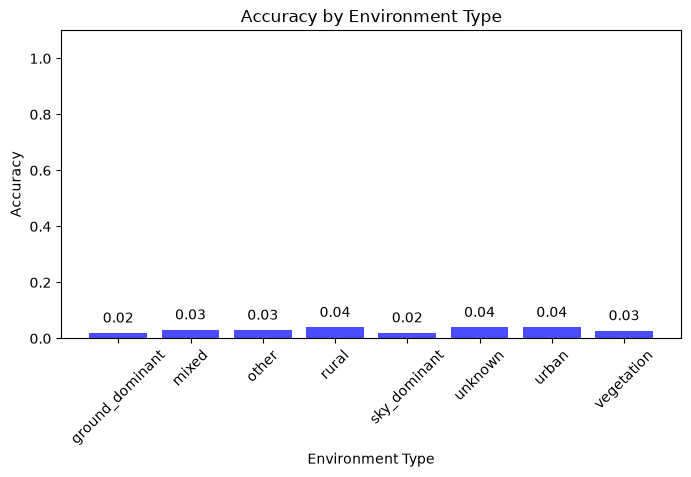

In [6]:
plot_single_bar_metric(environment_metrics, x_column='environment_type', metric='accuracy', title='Accuracy by Environment Type', ylabel='Accuracy', xlabel='Environment Type')

### Precision

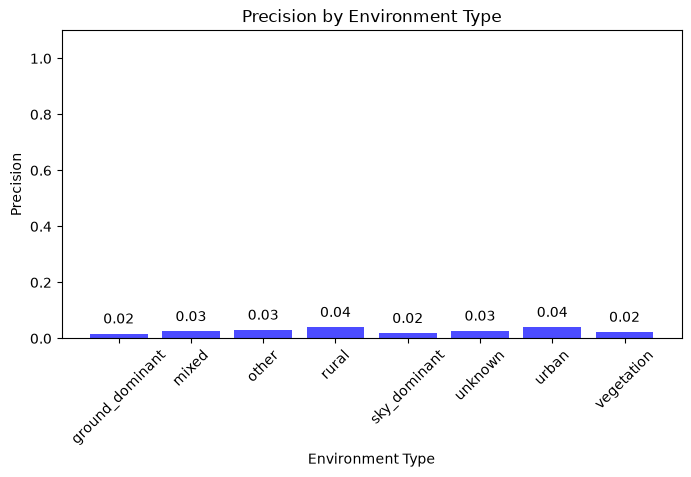

In [7]:
plot_single_bar_metric(environment_metrics, x_column='environment_type', metric='precision', title='Precision by Environment Type', ylabel='Precision', xlabel='Environment Type')

### Recall

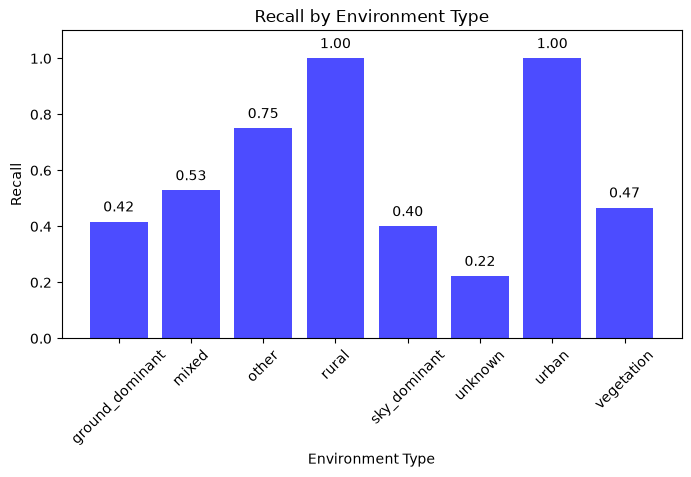

In [8]:
plot_single_bar_metric(environment_metrics, x_column='environment_type', metric='recall', title='Recall by Environment Type', ylabel='Recall', xlabel='Environment Type')

### Hit Rate

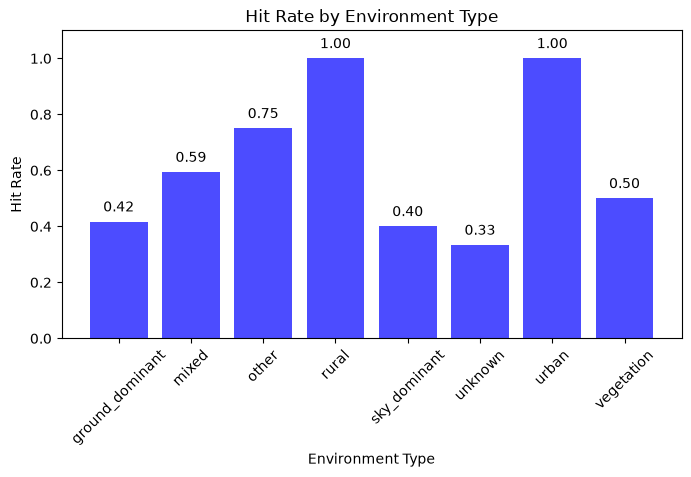

In [9]:
plot_single_bar_metric(environment_metrics, x_column='environment_type', metric='hit_rate', title='Hit Rate by Environment Type', ylabel='Hit Rate', xlabel='Environment Type')

### Diversity


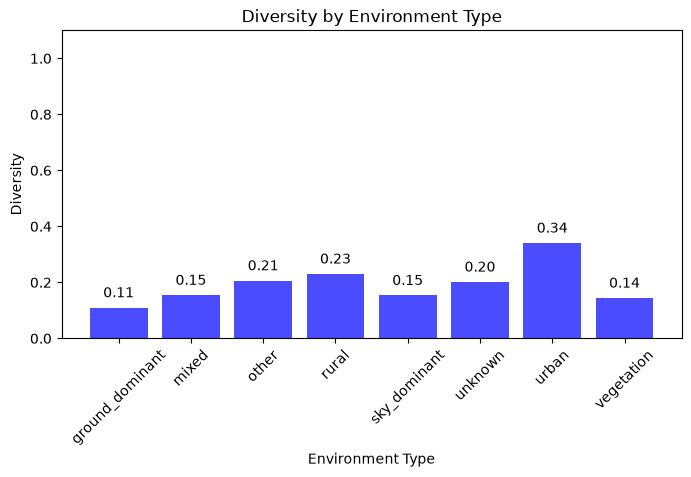

In [10]:
plot_single_bar_metric(environment_metrics, x_column='environment_type', metric='diversity', title='Diversity by Environment Type', ylabel='Diversity', xlabel='Environment Type')

### NDCG

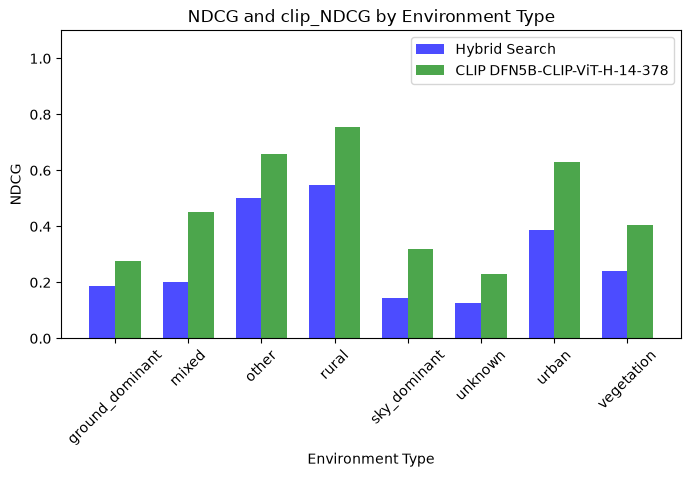

In [11]:
plot_rank_comparison(environment_metrics, x_column='environment_type', title='NDCG and clip_NDCG by Environment Type', xlabel='Environment Type')

### MRR

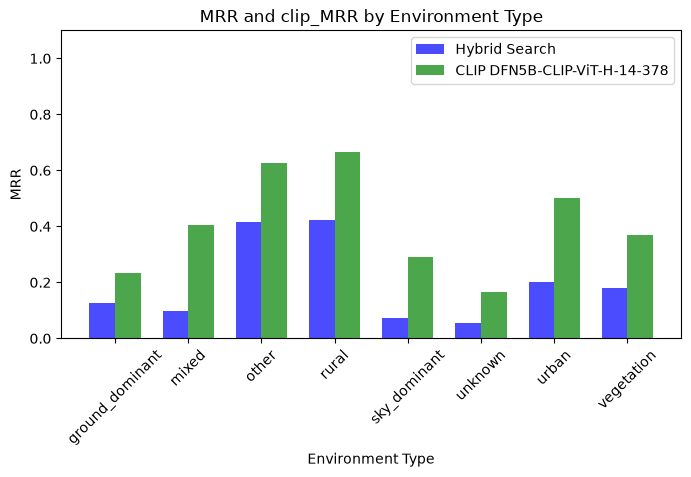

In [12]:
plot_rank_comparison(environment_metrics, x_column='environment_type', title='MRR and clip_MRR by Environment Type', xlabel='Environment Type', metric="MRR")

## Metrics based on Lighting

In [13]:


# Group by iconic_group and calculate the sum/mean of each metric
lighting_metrics = df.groupby(['lighting']).agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

#rename columns
lighting_metrics = lighting_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})

lighting_metrics

,lighting,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,day,1625,44,1581,39,1586,0.027077,0.024000,0.538462,0.569231,0.232610,0.461580,0.143145,0.423077,0.150728
1,dusk,75,5,70,4,71,0.066667,0.053333,0.466667,0.666667,0.236643,0.523547,0.092593,0.500000,0.117693
2,night,1025,23,1002,16,1009,0.022439,0.015610,0.345528,0.365854,0.157408,0.232987,0.103939,0.186585,0.153157
3,overcast_light,225,8,217,8,217,0.035556,0.035556,0.777778,0.777778,0.345248,0.681214,0.225154,0.648148,0.189330
4,unknown,50,0,50,0,50,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.163166


In [14]:
# Bar width
bar_width = 0.35
x = np.arange(len(lighting_metrics['lighting']))

### Accuracy

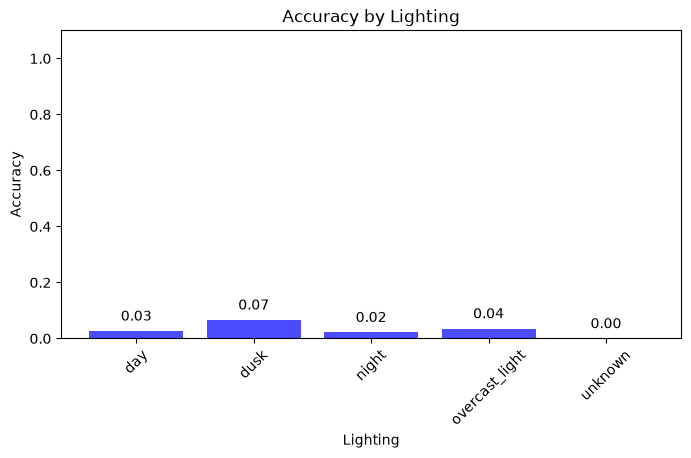

In [15]:
plot_single_bar_metric(lighting_metrics, x_column='lighting', metric='accuracy', title='Accuracy by Lighting', ylabel='Accuracy', xlabel='Lighting')

### Precision

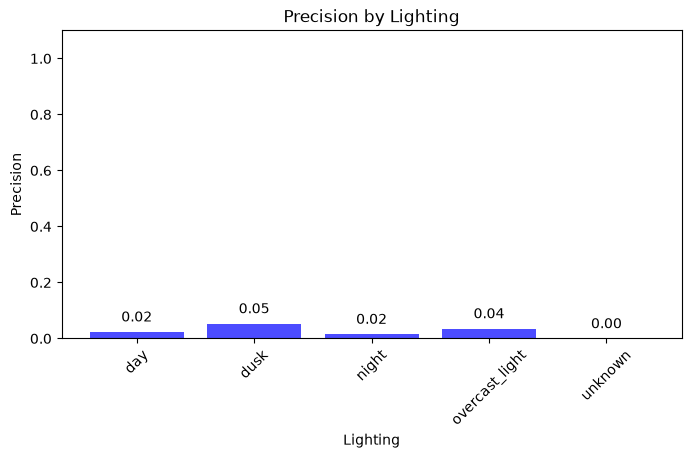

In [16]:
plot_single_bar_metric(lighting_metrics, x_column='lighting', metric='precision', title='Precision by Lighting', ylabel='Precision', xlabel='Lighting')

### Recall

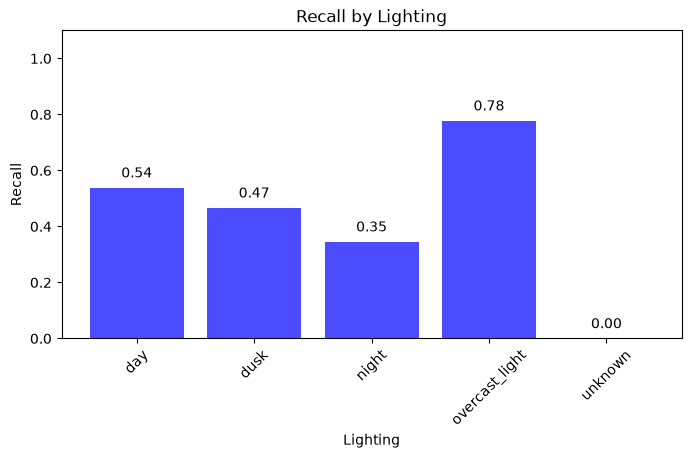

In [17]:
plot_single_bar_metric(lighting_metrics, x_column='lighting', metric='recall', title='Recall by Lighting', ylabel='Recall', xlabel='Lighting')

### Hit Rate

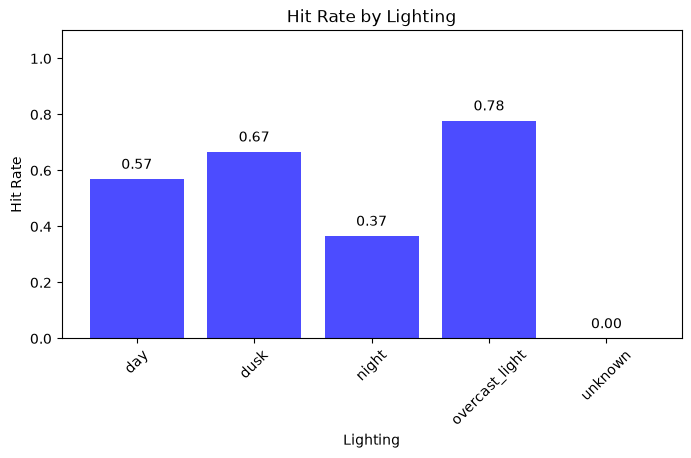

In [18]:
plot_single_bar_metric(lighting_metrics, x_column='lighting', metric='hit_rate', title='Hit Rate by Lighting', ylabel='Hit Rate', xlabel='Lighting')

### Diversity

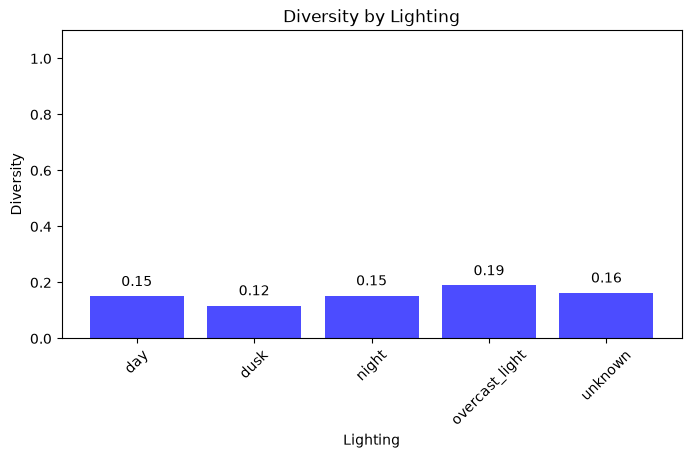

In [19]:
plot_single_bar_metric(lighting_metrics, x_column='lighting', metric='diversity', title='Diversity by Lighting', ylabel='Diversity', xlabel='Lighting')

### NDCG

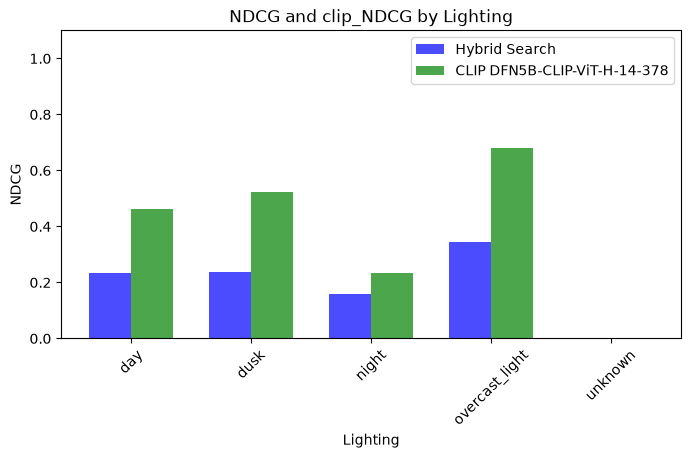

In [20]:
plot_rank_comparison(lighting_metrics, x_column='lighting', title='NDCG and clip_NDCG by Lighting', xlabel='Lighting')

### MRR

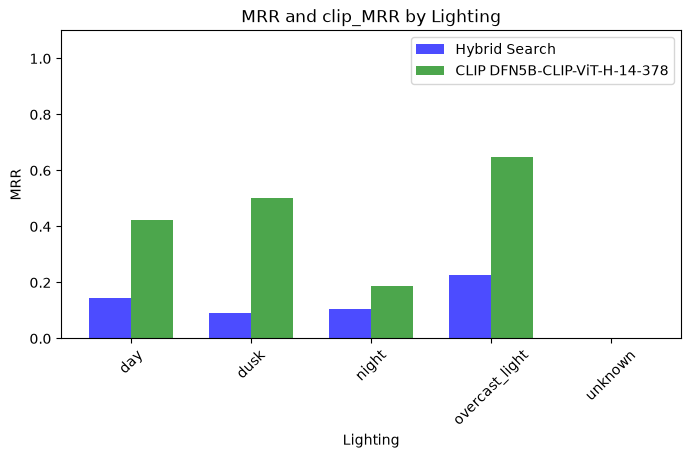

In [21]:
plot_rank_comparison(lighting_metrics, x_column='lighting', title='MRR and clip_MRR by Lighting', xlabel='Lighting', metric="MRR")

## Metrics based on Viewpoint

In [22]:
# Group by viewpoint and calculate the sum/mean of each metric
viewpoint_metrics = df.groupby('viewpoint').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

#rename columns
viewpoint_metrics = viewpoint_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})

viewpoint_metrics

,viewpoint,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,duo_view,50,3,47,1,49,0.060000,0.020000,0.500000,0.500000,0.117704,0.250000,0.027778,0.166667,0.200229
1,fisheye_sky,700,17,683,15,685,0.024286,0.021429,0.464286,0.464286,0.171101,0.381237,0.089829,0.351190,0.146142
2,ground_horizontal,1925,50,1875,43,1882,0.025974,0.022338,0.485714,0.519481,0.227229,0.397751,0.150146,0.356926,0.153434
3,ground_upward,150,3,147,3,147,0.020000,0.020000,0.500000,0.500000,0.288618,0.355155,0.226852,0.305556,0.198876
4,oblique,125,4,121,3,122,0.032000,0.024000,0.500000,0.600000,0.152112,0.526186,0.042051,0.500000,0.115917
5,unknown,50,3,47,2,48,0.060000,0.040000,0.333333,0.500000,0.187674,0.346713,0.083333,0.250000,0.190221


### Accuracy

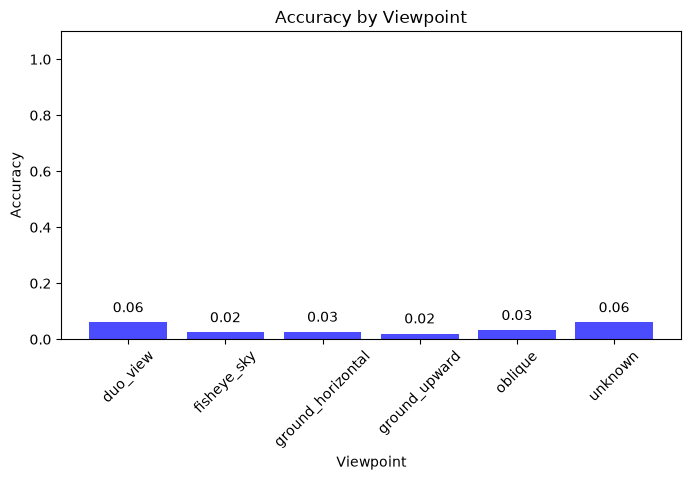

In [23]:
plot_single_bar_metric(viewpoint_metrics, x_column='viewpoint', metric='accuracy', title='Accuracy by Viewpoint', ylabel='Accuracy', xlabel='Viewpoint')

### Precision

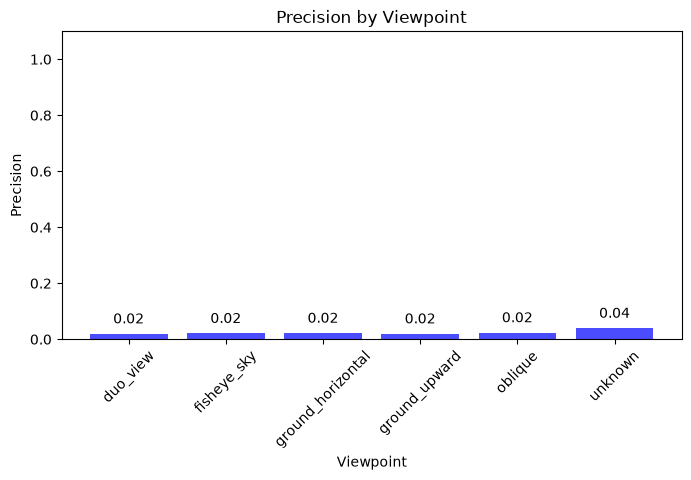

In [24]:
plot_single_bar_metric(viewpoint_metrics, x_column='viewpoint', metric='precision', title='Precision by Viewpoint', ylabel='Precision', xlabel='Viewpoint')

### Recall

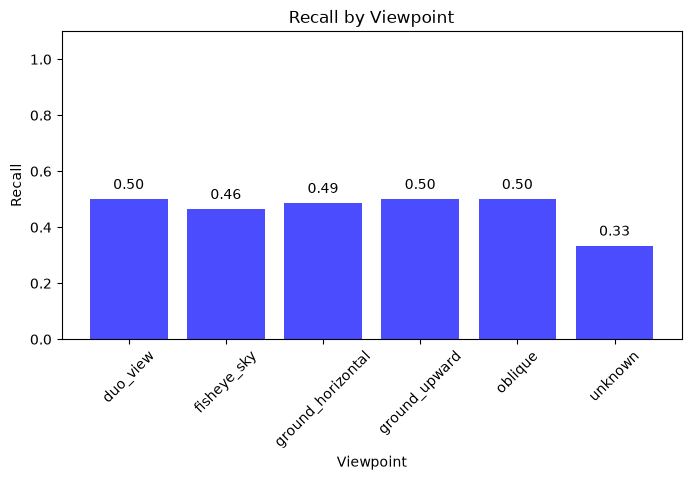

In [25]:
plot_single_bar_metric(viewpoint_metrics, x_column='viewpoint', metric='recall', title='Recall by Viewpoint', ylabel='Recall', xlabel='Viewpoint')

### Hit Rate

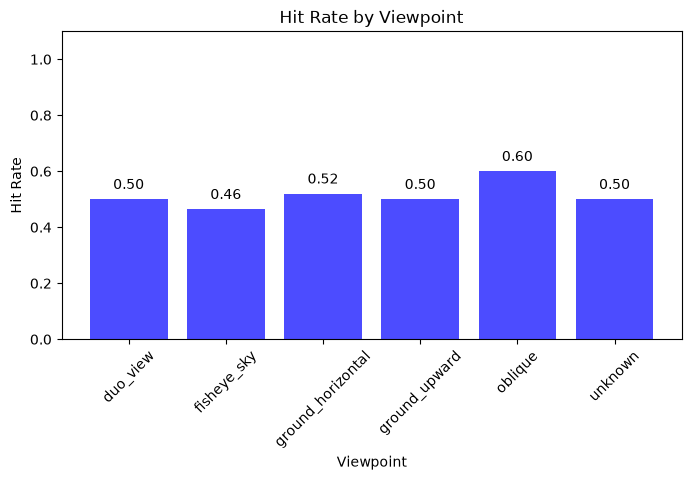

In [26]:
plot_single_bar_metric(viewpoint_metrics, x_column='viewpoint', metric='hit_rate', title='Hit Rate by Viewpoint', ylabel='Hit Rate', xlabel='Viewpoint')

### Diversity

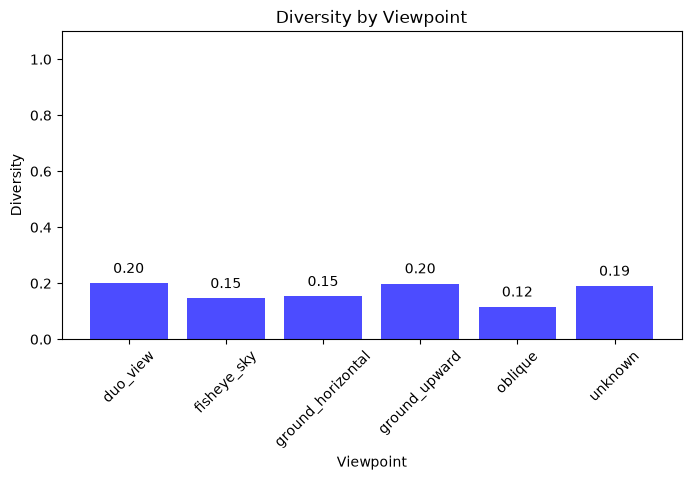

In [27]:
plot_single_bar_metric(viewpoint_metrics, x_column='viewpoint', metric='diversity', title='Diversity by Viewpoint', ylabel='Diversity', xlabel='Viewpoint')

### NDCG

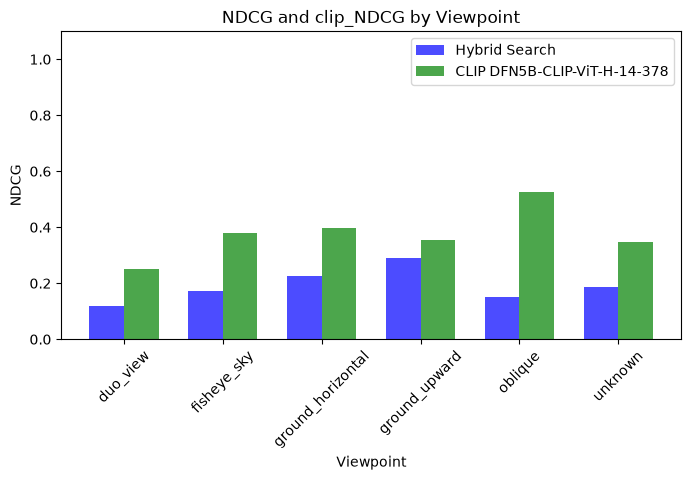

In [28]:
plot_rank_comparison(viewpoint_metrics, x_column='viewpoint', title='NDCG and clip_NDCG by Viewpoint', xlabel='Viewpoint')

### MRR

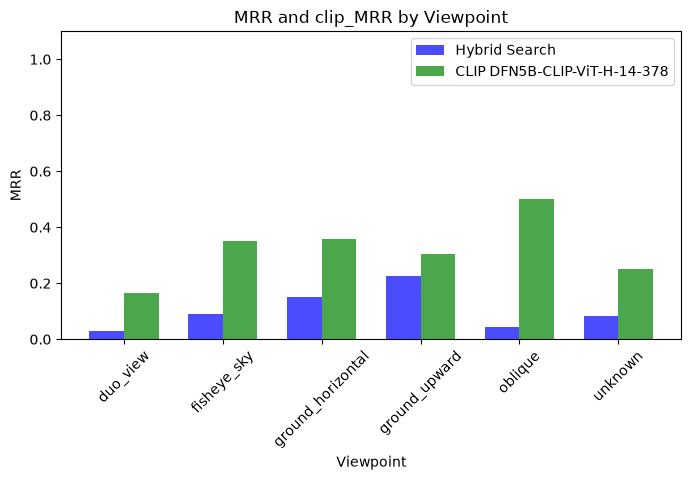

In [29]:
plot_rank_comparison(viewpoint_metrics, x_column='viewpoint', title='MRR and clip_MRR by Viewpoint', xlabel='Viewpoint', metric="MRR")

## Metrics based on Sky Condition

Now, we will evaluate queries based on sky condition.


In [30]:
# Group by sky_condition and calculate the sum/mean of each metric
sky_condition_metrics = df.groupby('sky_condition').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

#rename columns
sky_condition_metrics = sky_condition_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})

sky_condition_metrics


,sky_condition,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,clear,1000,25,975,18,982,0.025000,0.018000,0.420833,0.450000,0.191836,0.320084,0.124593,0.275833,0.159012
1,fog_or_haze,225,6,219,6,219,0.026667,0.026667,0.611111,0.666667,0.280917,0.611111,0.178924,0.592593,0.147197
2,other,25,1,24,1,24,0.040000,0.040000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.255080
3,overcast,500,16,484,15,485,0.032000,0.030000,0.650000,0.650000,0.232708,0.551186,0.113063,0.516667,0.175825
4,partly_cloudy,700,21,679,19,681,0.030000,0.027143,0.520238,0.571429,0.206352,0.431698,0.113906,0.383929,0.136455
5,unknown,550,11,539,8,542,0.020000,0.014545,0.303030,0.318182,0.170765,0.220097,0.128427,0.183333,0.144662


### Accuracy


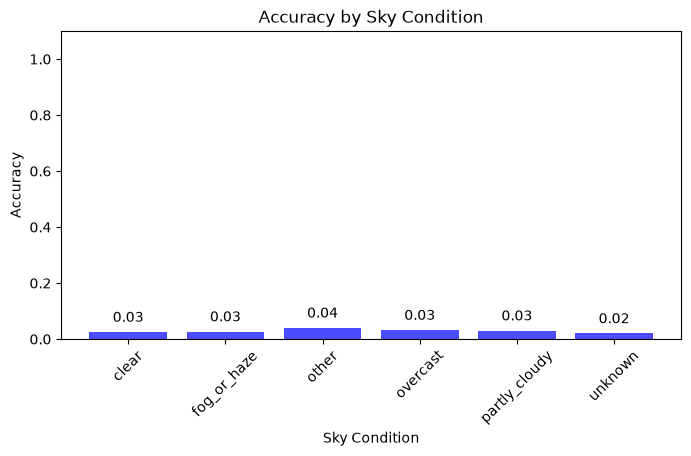

In [31]:
plot_single_bar_metric(sky_condition_metrics, x_column='sky_condition', metric='accuracy', title='Accuracy by Sky Condition', ylabel='Accuracy', xlabel='Sky Condition')


### Precision


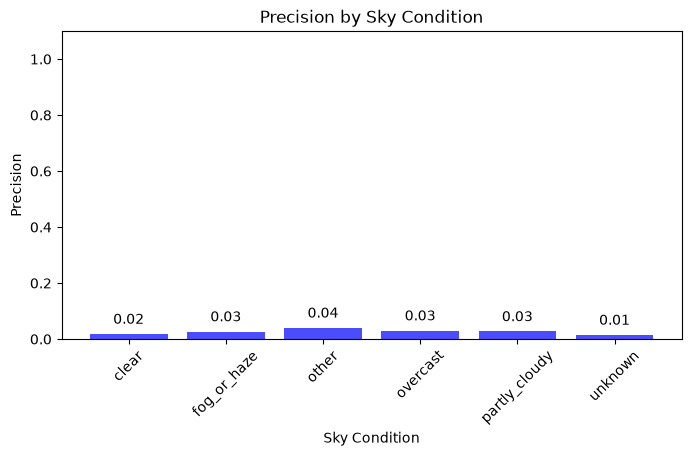

In [32]:
plot_single_bar_metric(sky_condition_metrics, x_column='sky_condition', metric='precision', title='Precision by Sky Condition', ylabel='Precision', xlabel='Sky Condition')


### Recall


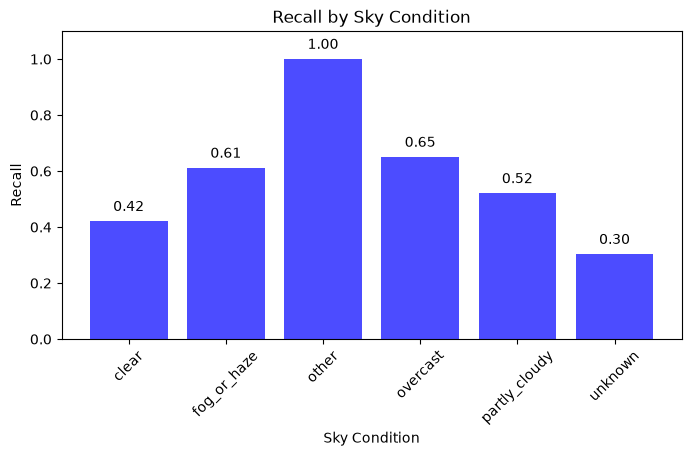

In [33]:
plot_single_bar_metric(sky_condition_metrics, x_column='sky_condition', metric='recall', title='Recall by Sky Condition', ylabel='Recall', xlabel='Sky Condition')


### Hit Rate


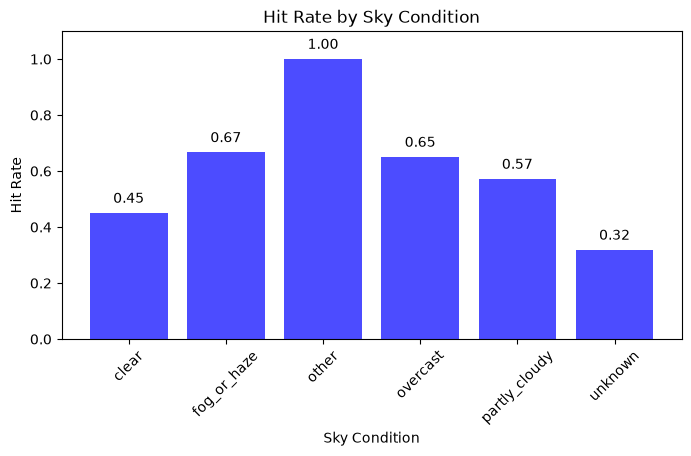

In [34]:
plot_single_bar_metric(sky_condition_metrics, x_column='sky_condition', metric='hit_rate', title='Hit Rate by Sky Condition', ylabel='Hit Rate', xlabel='Sky Condition')


### Diversity


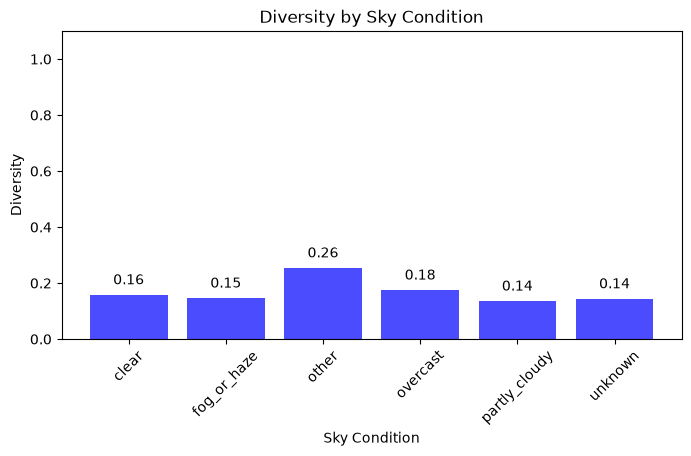

In [35]:
plot_single_bar_metric(sky_condition_metrics, x_column='sky_condition', metric='diversity', title='Diversity by Sky Condition', ylabel='Diversity', xlabel='Sky Condition')


### NDCG


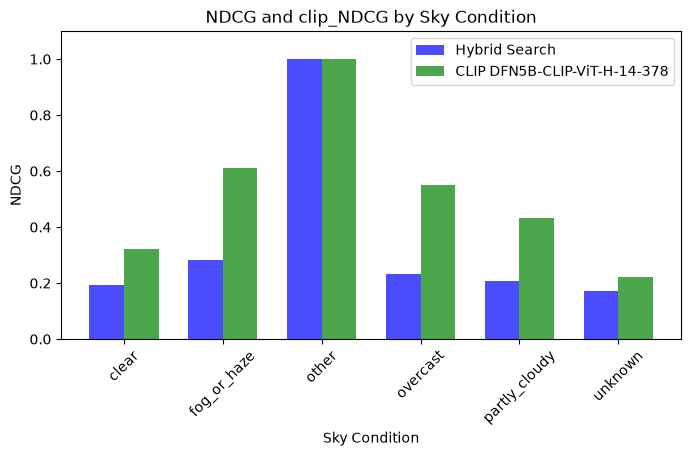

In [36]:
plot_rank_comparison(sky_condition_metrics, x_column='sky_condition', title='NDCG and clip_NDCG by Sky Condition', xlabel='Sky Condition')


### MRR


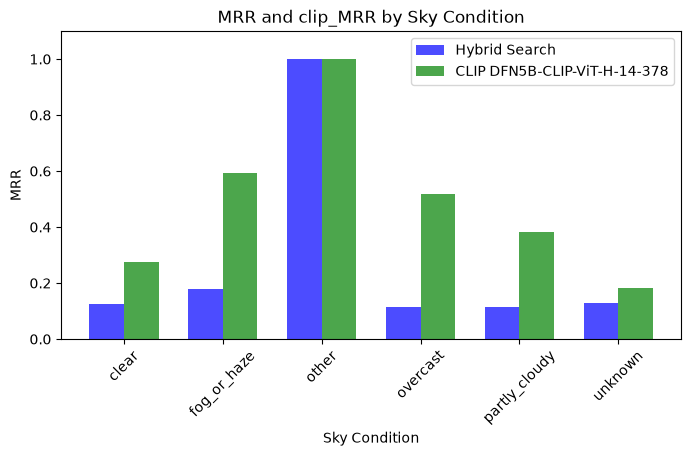

In [37]:
plot_rank_comparison(sky_condition_metrics, x_column='sky_condition', title='MRR and clip_MRR by Sky Condition', xlabel='Sky Condition', metric="MRR")


## Metrics based on Horizon Present

Now, we will evaluate queries based on **Horizon Present** (true vs false).


In [38]:
# Group by horizon_present and calculate the sum/mean of each metric
horizon_present_metrics = df.groupby('horizon_present').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

# use true and false instead of 1 and 0
horizon_present_metrics['horizon_present'] = horizon_present_metrics['horizon_present'].map({True: 'True', False: 'False'})

#rename columns
horizon_present_metrics = horizon_present_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})
horizon_present_metrics = horizon_present_metrics.sort_values('horizon_present')

horizon_present_metrics


,horizon_present,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,850,18,832,15,835,0.021176,0.017647,0.387255,0.411765,0.201736,0.333592,0.142390,0.304902,0.157729
1,True,2150,62,2088,52,2098,0.028837,0.024186,0.516279,0.546512,0.215483,0.417612,0.128242,0.373450,0.152295


### Accuracy


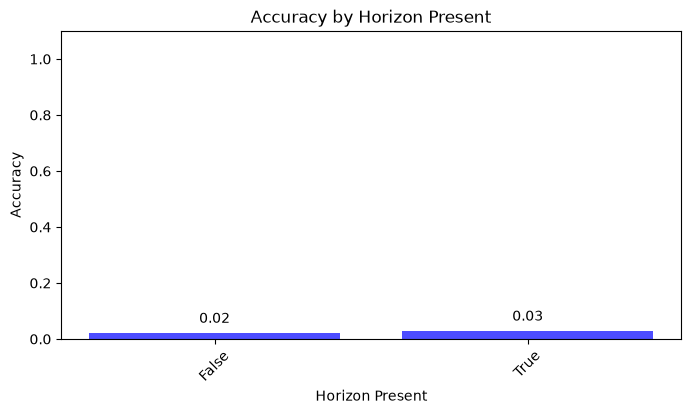

In [39]:
plot_single_bar_metric(horizon_present_metrics, x_column='horizon_present', metric='accuracy', title='Accuracy by Horizon Present', ylabel='Accuracy', xlabel='Horizon Present')


### Precision


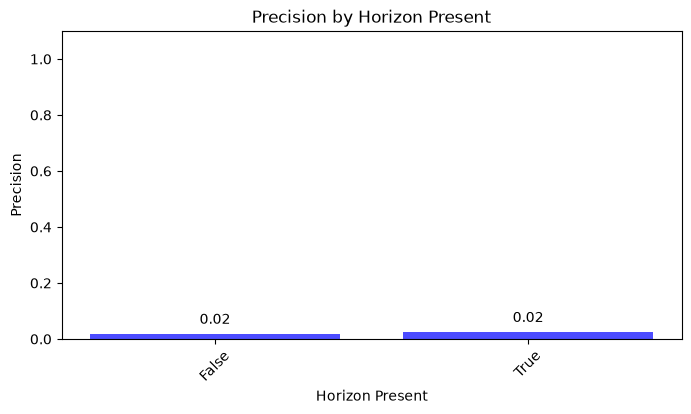

In [40]:
plot_single_bar_metric(horizon_present_metrics, x_column='horizon_present', metric='precision', title='Precision by Horizon Present', ylabel='Precision', xlabel='Horizon Present')


### Recall


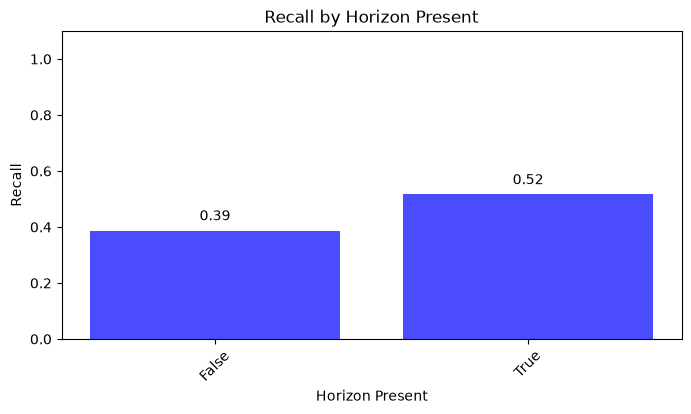

In [41]:
plot_single_bar_metric(horizon_present_metrics, x_column='horizon_present', metric='recall', title='Recall by Horizon Present', ylabel='Recall', xlabel='Horizon Present')


### Hit Rate


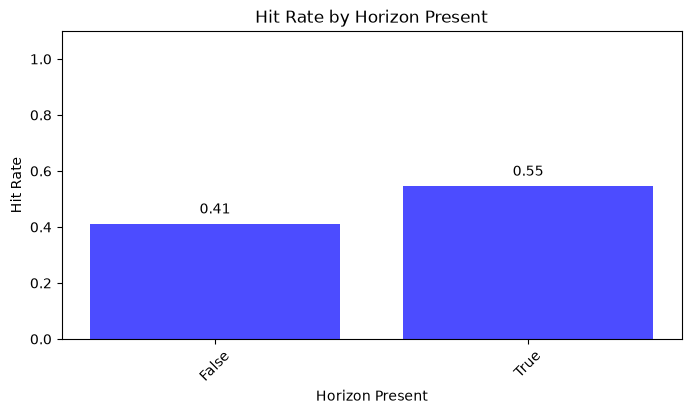

In [42]:
plot_single_bar_metric(horizon_present_metrics, x_column='horizon_present', metric='hit_rate', title='Hit Rate by Horizon Present', ylabel='Hit Rate', xlabel='Horizon Present')


### Diversity


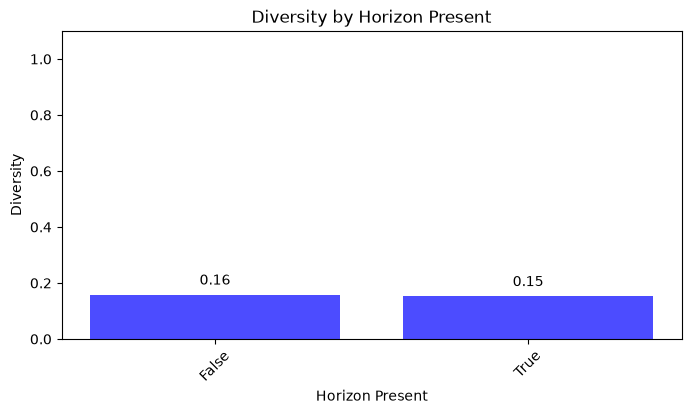

In [43]:
plot_single_bar_metric(horizon_present_metrics, x_column='horizon_present', metric='diversity', title='Diversity by Horizon Present', ylabel='Diversity', xlabel='Horizon Present')


### NDCG


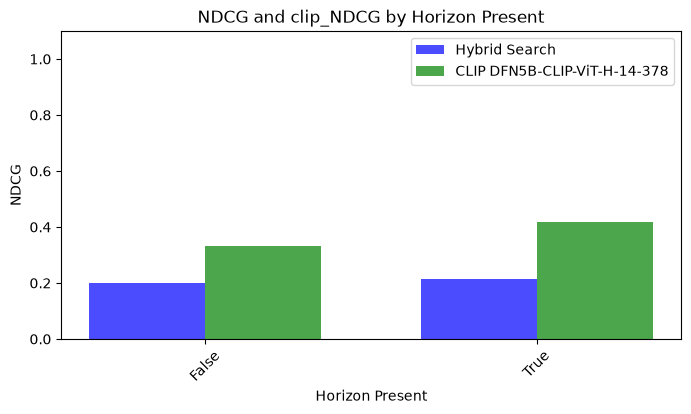

In [44]:
plot_rank_comparison(horizon_present_metrics, x_column='horizon_present', title='NDCG and clip_NDCG by Horizon Present', xlabel='Horizon Present')


### MRR


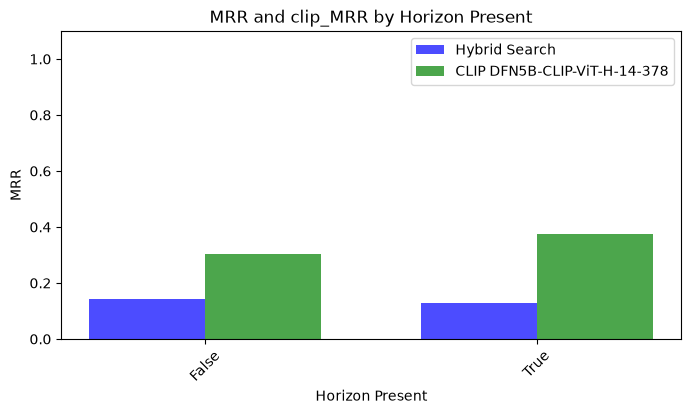

In [45]:
plot_rank_comparison(horizon_present_metrics, x_column='horizon_present', title='MRR and clip_MRR by Horizon Present', xlabel='Horizon Present', metric="MRR")


## Metrics based on Ground Present

Now, we will evaluate queries based on **Ground Present** (true vs false).


In [46]:
# Group by ground_present and calculate the sum/mean of each metric
ground_present_metrics = df.groupby('ground_present').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

# use true and false instead of 1 and 0
ground_present_metrics['ground_present'] = ground_present_metrics['ground_present'].map({True: 'True', False: 'False'})


#rename columns
ground_present_metrics = ground_present_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})
ground_present_metrics = ground_present_metrics.sort_values('ground_present')

ground_present_metrics


,ground_present,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,475,11,464,9,466,0.023158,0.018947,0.350877,0.368421,0.130150,0.287120,0.058918,0.254386,0.165402
1,True,2525,69,2456,58,2467,0.027327,0.022970,0.503960,0.534653,0.226908,0.413876,0.146046,0.372772,0.151658


### Accuracy


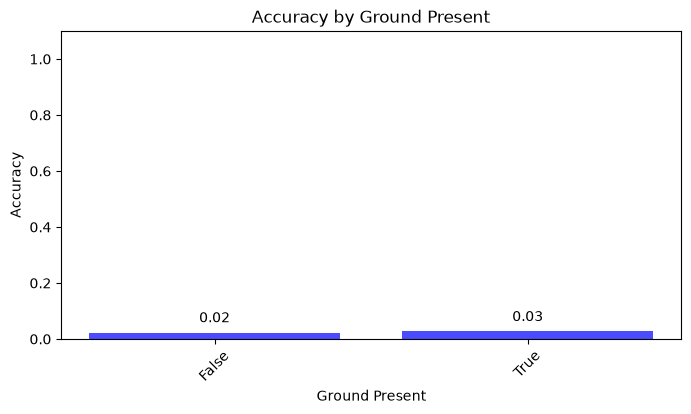

In [47]:
plot_single_bar_metric(ground_present_metrics, x_column='ground_present', metric='accuracy', title='Accuracy by Ground Present', ylabel='Accuracy', xlabel='Ground Present')


### Precision


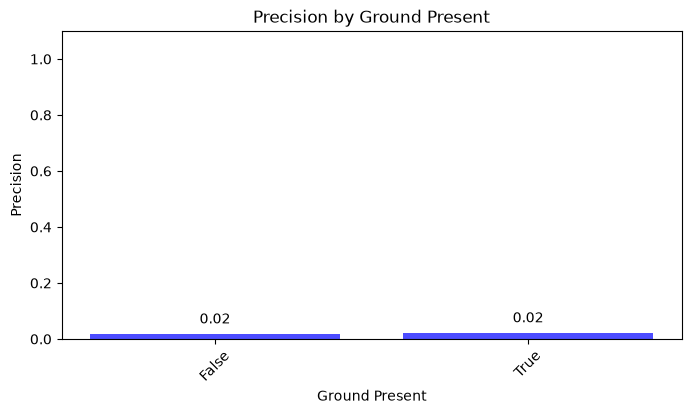

In [48]:
plot_single_bar_metric(ground_present_metrics, x_column='ground_present', metric='precision', title='Precision by Ground Present', ylabel='Precision', xlabel='Ground Present')


### Recall


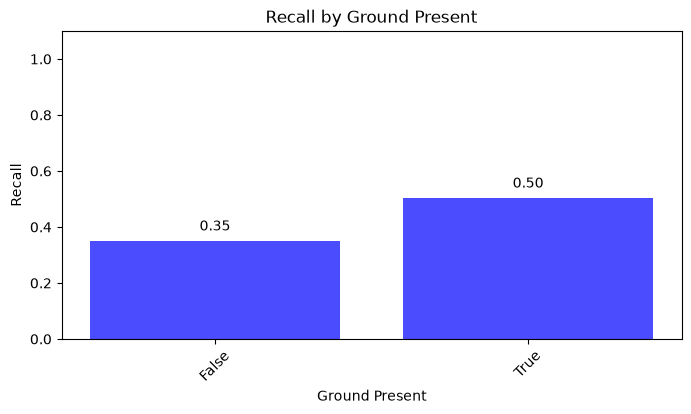

In [49]:
plot_single_bar_metric(ground_present_metrics, x_column='ground_present', metric='recall', title='Recall by Ground Present', ylabel='Recall', xlabel='Ground Present')


### Hit Rate


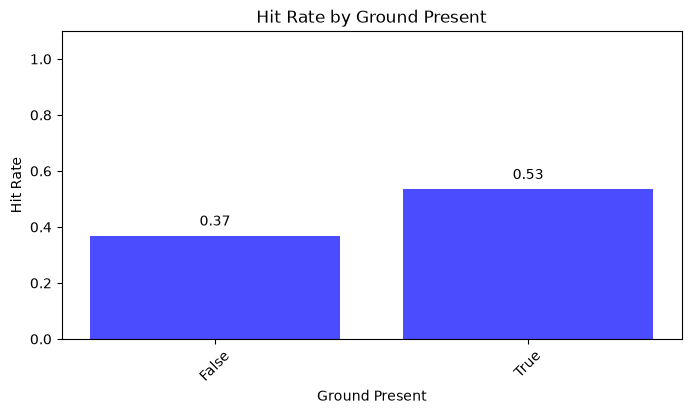

In [50]:
plot_single_bar_metric(ground_present_metrics, x_column='ground_present', metric='hit_rate', title='Hit Rate by Ground Present', ylabel='Hit Rate', xlabel='Ground Present')


### Diversity


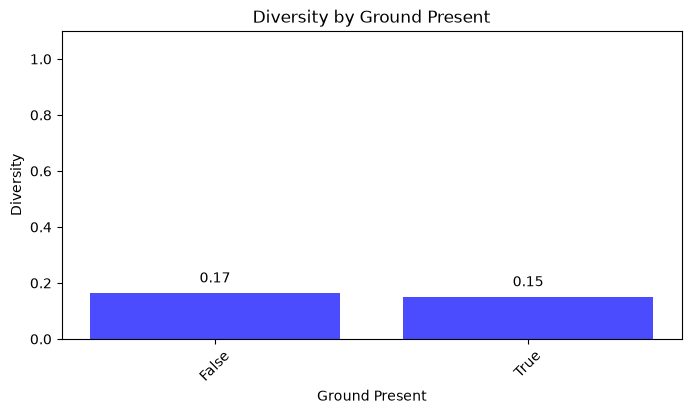

In [51]:
plot_single_bar_metric(ground_present_metrics, x_column='ground_present', metric='diversity', title='Diversity by Ground Present', ylabel='Diversity', xlabel='Ground Present')


### NDCG


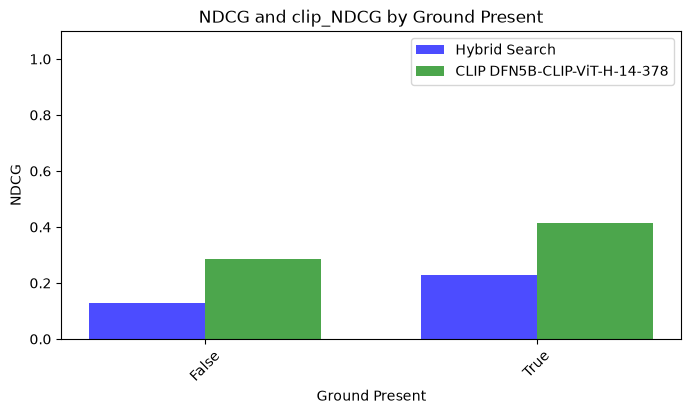

In [52]:
plot_rank_comparison(ground_present_metrics, x_column='ground_present', title='NDCG and clip_NDCG by Ground Present', xlabel='Ground Present')


### MRR


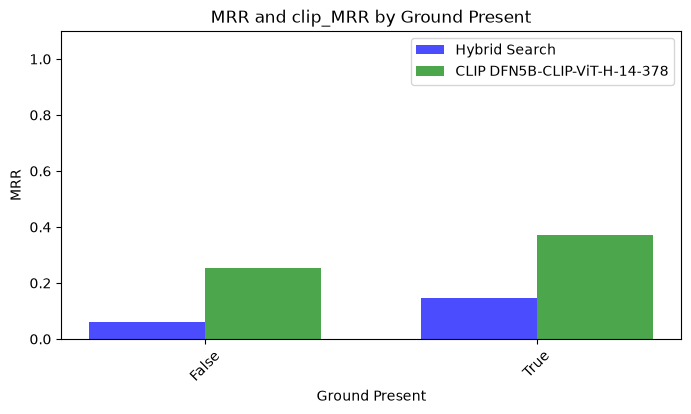

In [53]:
plot_rank_comparison(ground_present_metrics, x_column='ground_present', title='MRR and clip_MRR by Ground Present', xlabel='Ground Present', metric="MRR")


## Metrics based on Sky Dominates

Now, we will evaluate queries based on **Sky Dominates** (true vs false).


In [54]:
# Group by sky_dominates and calculate the sum/mean of each metric
sky_dominates_metrics = df.groupby('sky_dominates').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

sky_dominates_metrics['sky_dominates'] = sky_dominates_metrics['sky_dominates'].map({True: 'True', False: 'False'})

#rename columns
sky_dominates_metrics = sky_dominates_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})
sky_dominates_metrics = sky_dominates_metrics.sort_values('sky_dominates')

sky_dominates_metrics


,sky_dominates,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,1800,48,1752,39,1761,0.026667,0.021667,0.467593,0.500000,0.211407,0.390897,0.136037,0.351157,0.146666
1,True,1200,32,1168,28,1172,0.026667,0.023333,0.497917,0.520833,0.211858,0.398170,0.126571,0.358333,0.164587


### Accuracy


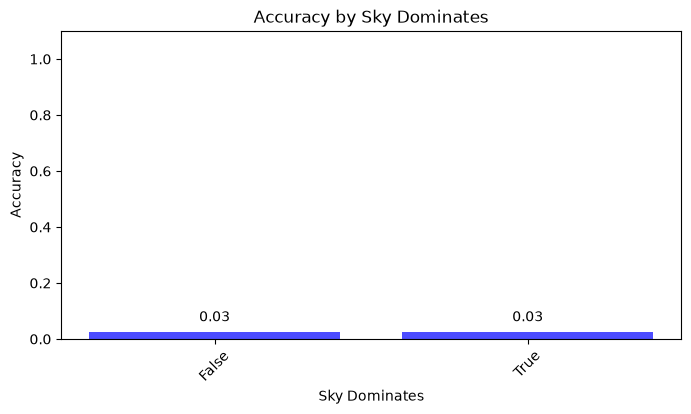

In [55]:
plot_single_bar_metric(sky_dominates_metrics, x_column='sky_dominates', metric='accuracy', title='Accuracy by Sky Dominates', ylabel='Accuracy', xlabel='Sky Dominates')


### Precision


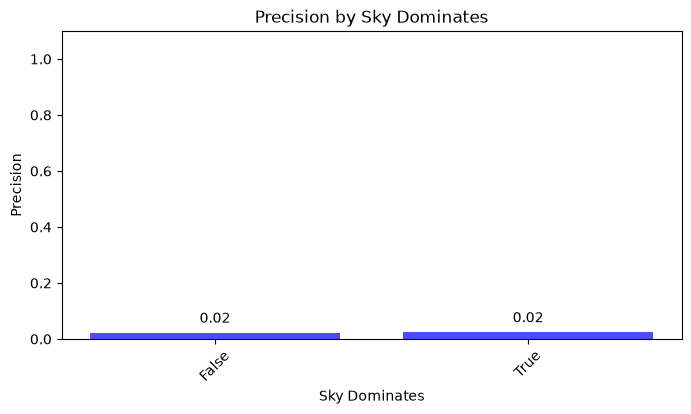

In [56]:
plot_single_bar_metric(sky_dominates_metrics, x_column='sky_dominates', metric='precision', title='Precision by Sky Dominates', ylabel='Precision', xlabel='Sky Dominates')


### Recall


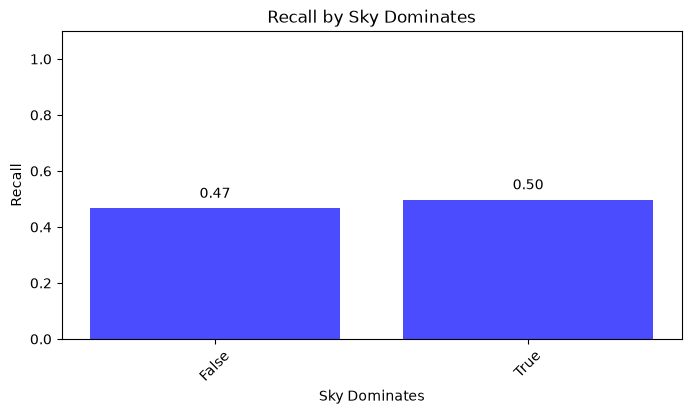

In [57]:
plot_single_bar_metric(sky_dominates_metrics, x_column='sky_dominates', metric='recall', title='Recall by Sky Dominates', ylabel='Recall', xlabel='Sky Dominates')


### Hit Rate


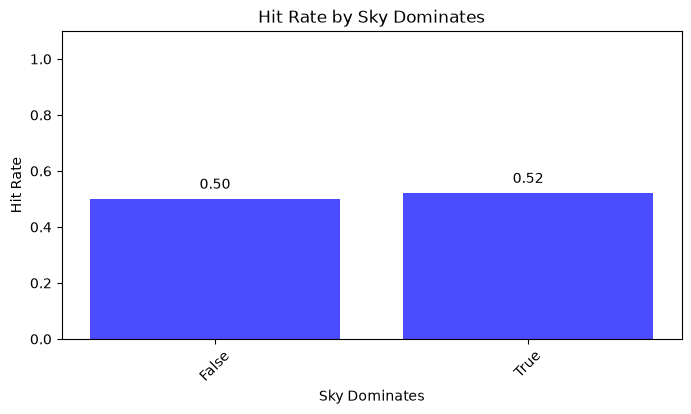

In [58]:
plot_single_bar_metric(sky_dominates_metrics, x_column='sky_dominates', metric='hit_rate', title='Hit Rate by Sky Dominates', ylabel='Hit Rate', xlabel='Sky Dominates')


### Diversity


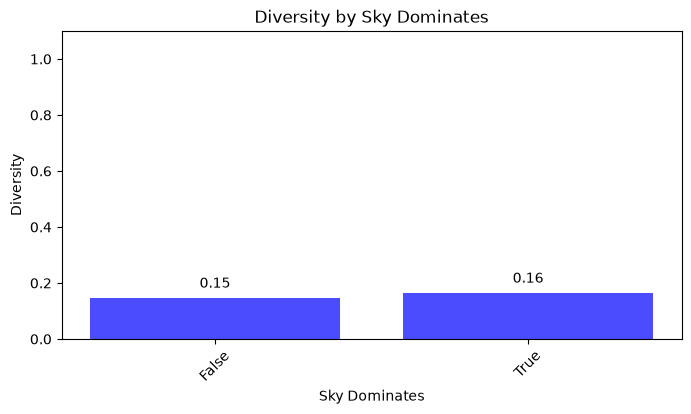

In [59]:
plot_single_bar_metric(sky_dominates_metrics, x_column='sky_dominates', metric='diversity', title='Diversity by Sky Dominates', ylabel='Diversity', xlabel='Sky Dominates')


### NDCG


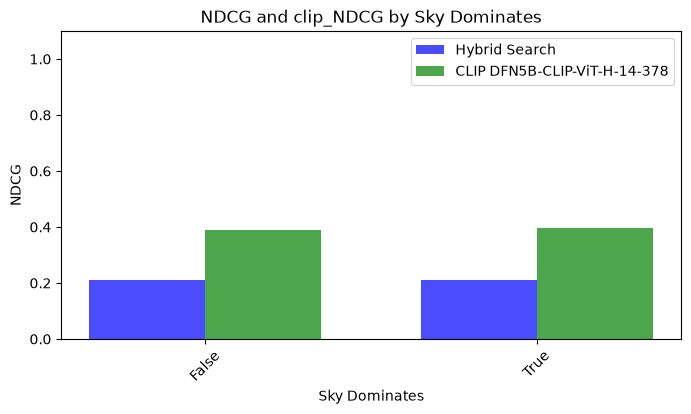

In [60]:
plot_rank_comparison(sky_dominates_metrics, x_column='sky_dominates', title='NDCG and clip_NDCG by Sky Dominates', xlabel='Sky Dominates')


### MRR


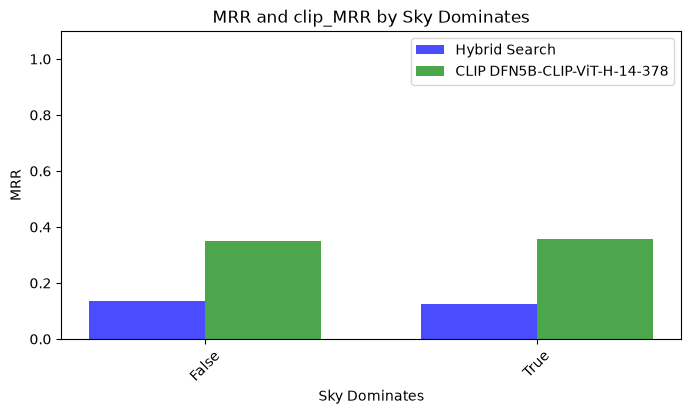

In [61]:
plot_rank_comparison(sky_dominates_metrics, x_column='sky_dominates', title='MRR and clip_MRR by Sky Dominates', xlabel='Sky Dominates', metric="MRR")


## Metrics based on Vegetation Present

Now, we will evaluate queries based on **Vegetation Present** (true vs false).


In [62]:
# Group by vegetation_present and calculate the sum/mean of each metric
vegetation_present_metrics = df.groupby('vegetation_present').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

vegetation_present_metrics['vegetation_present'] = vegetation_present_metrics['vegetation_present'].map({True: 'True', False: 'False'})


#rename columns
vegetation_present_metrics = vegetation_present_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})
vegetation_present_metrics = vegetation_present_metrics.sort_values('vegetation_present')

vegetation_present_metrics


,vegetation_present,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,1125,24,1101,21,1104,0.021333,0.018667,0.403704,0.422222,0.171413,0.345215,0.100510,0.317407,0.143838
1,True,1875,56,1819,46,1829,0.029867,0.024533,0.525333,0.560000,0.235692,0.422961,0.151295,0.376000,0.159832


### Accuracy


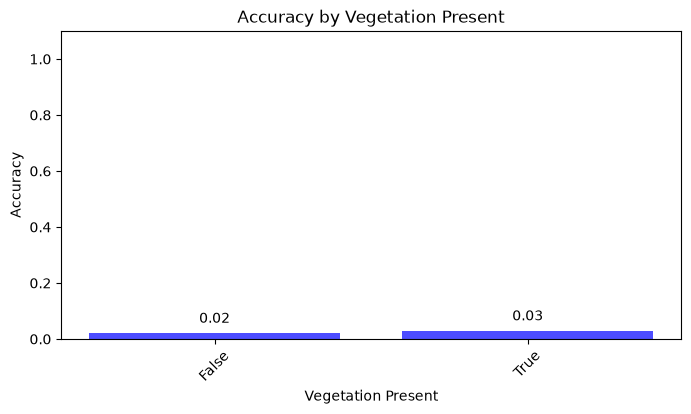

In [63]:
plot_single_bar_metric(vegetation_present_metrics, x_column='vegetation_present', metric='accuracy', title='Accuracy by Vegetation Present', ylabel='Accuracy', xlabel='Vegetation Present')


### Precision


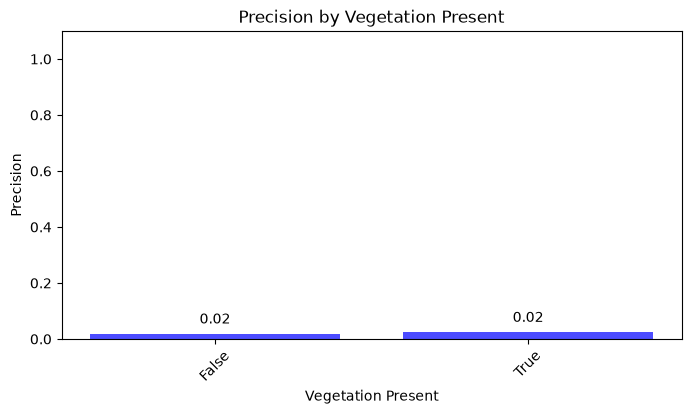

In [64]:
plot_single_bar_metric(vegetation_present_metrics, x_column='vegetation_present', metric='precision', title='Precision by Vegetation Present', ylabel='Precision', xlabel='Vegetation Present')


### Recall


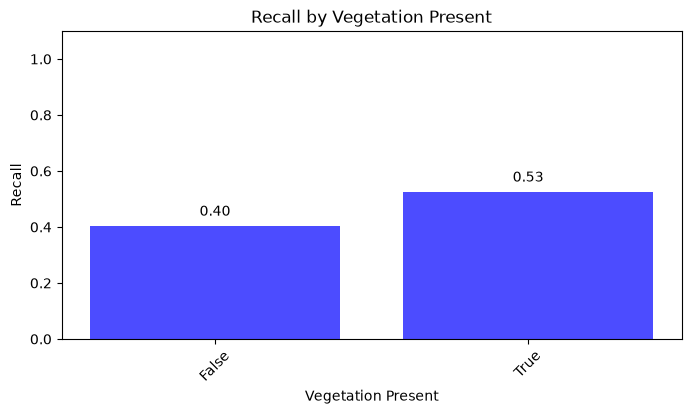

In [65]:
plot_single_bar_metric(vegetation_present_metrics, x_column='vegetation_present', metric='recall', title='Recall by Vegetation Present', ylabel='Recall', xlabel='Vegetation Present')


### Hit Rate


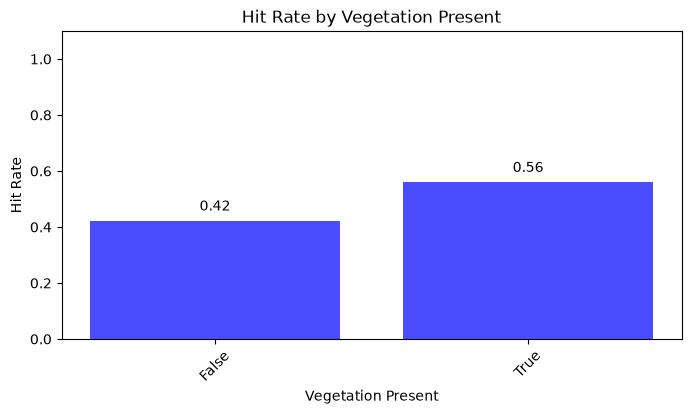

In [66]:
plot_single_bar_metric(vegetation_present_metrics, x_column='vegetation_present', metric='hit_rate', title='Hit Rate by Vegetation Present', ylabel='Hit Rate', xlabel='Vegetation Present')


### Diversity


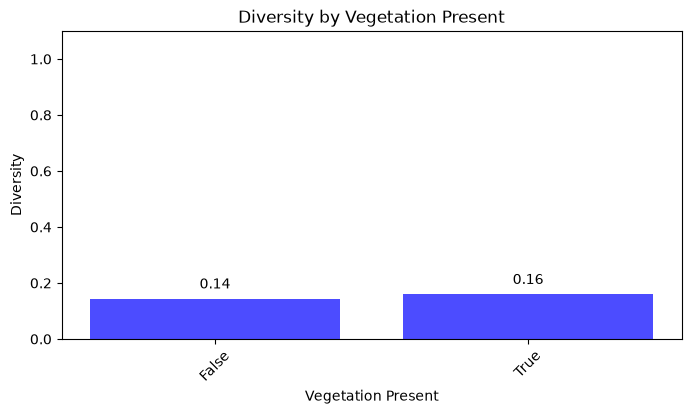

In [67]:
plot_single_bar_metric(vegetation_present_metrics, x_column='vegetation_present', metric='diversity', title='Diversity by Vegetation Present', ylabel='Diversity', xlabel='Vegetation Present')


### NDCG


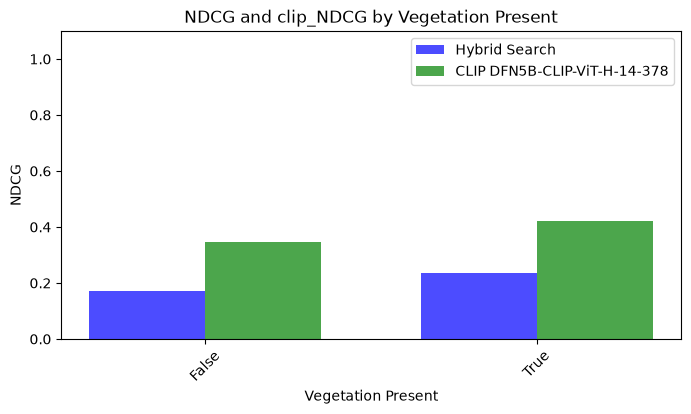

In [68]:
plot_rank_comparison(vegetation_present_metrics, x_column='vegetation_present', title='NDCG and clip_NDCG by Vegetation Present', xlabel='Vegetation Present')


### MRR


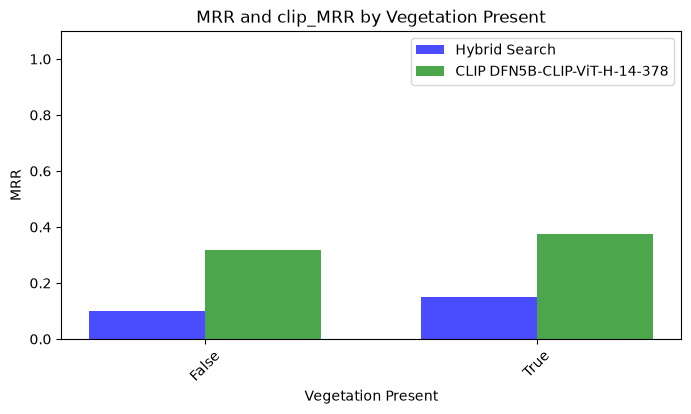

In [69]:
plot_rank_comparison(vegetation_present_metrics, x_column='vegetation_present', title='MRR and clip_MRR by Vegetation Present', xlabel='Vegetation Present', metric="MRR")


## Metrics based on Water Present

Now, we will evaluate queries based on **Water Present** (true vs false).


In [70]:
# Group by water_present and calculate the sum/mean of each metric
water_present_metrics = df.groupby('water_present').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

water_present_metrics['water_present'] = water_present_metrics['water_present'].map({True: 'True', False: 'False'})

#rename columns
water_present_metrics = water_present_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})
water_present_metrics = water_present_metrics.sort_values('water_present')

water_present_metrics


,water_present,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,2825,72,2753,61,2764,0.025487,0.021593,0.456342,0.486726,0.196825,0.371636,0.120126,0.331711,0.147360
1,True,175,8,167,6,169,0.045714,0.034286,0.857143,0.857143,0.449898,0.751694,0.327976,0.714286,0.258353


### Accuracy


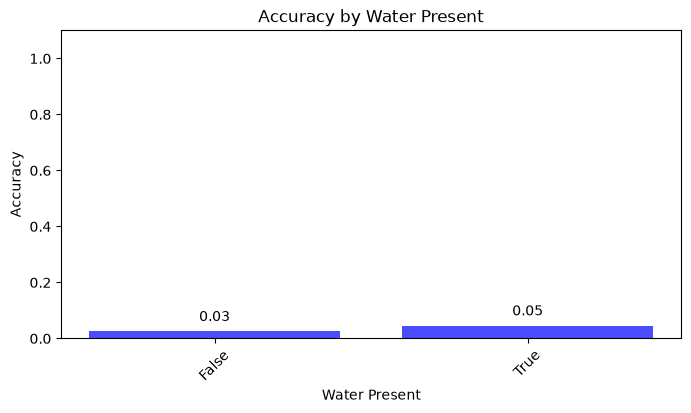

In [71]:
plot_single_bar_metric(water_present_metrics, x_column='water_present', metric='accuracy', title='Accuracy by Water Present', ylabel='Accuracy', xlabel='Water Present')


### Precision


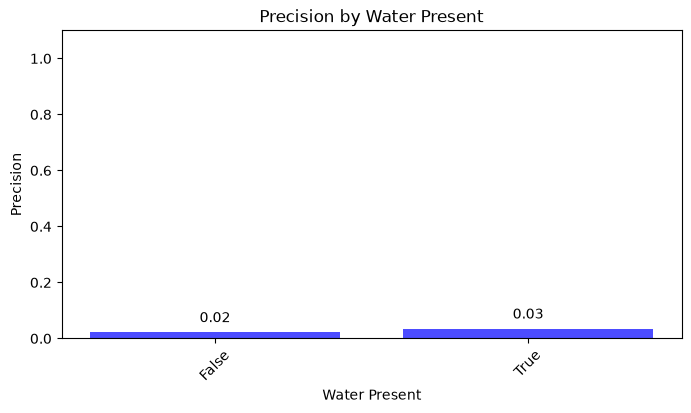

In [72]:
plot_single_bar_metric(water_present_metrics, x_column='water_present', metric='precision', title='Precision by Water Present', ylabel='Precision', xlabel='Water Present')


### Recall


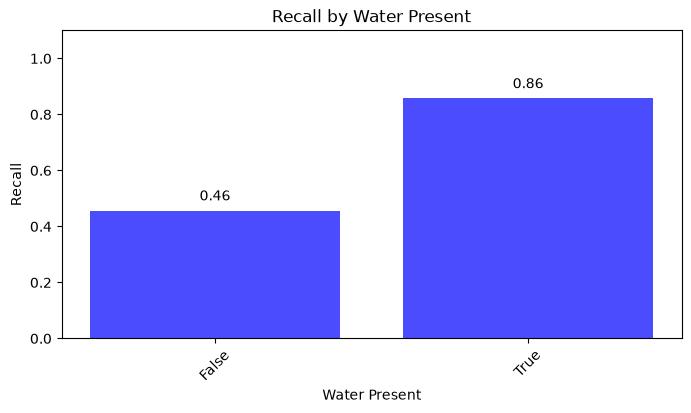

In [73]:
plot_single_bar_metric(water_present_metrics, x_column='water_present', metric='recall', title='Recall by Water Present', ylabel='Recall', xlabel='Water Present')


### Hit Rate


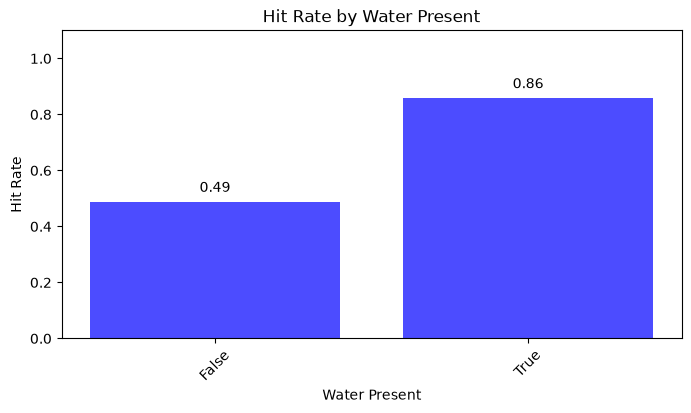

In [74]:
plot_single_bar_metric(water_present_metrics, x_column='water_present', metric='hit_rate', title='Hit Rate by Water Present', ylabel='Hit Rate', xlabel='Water Present')


### Diversity


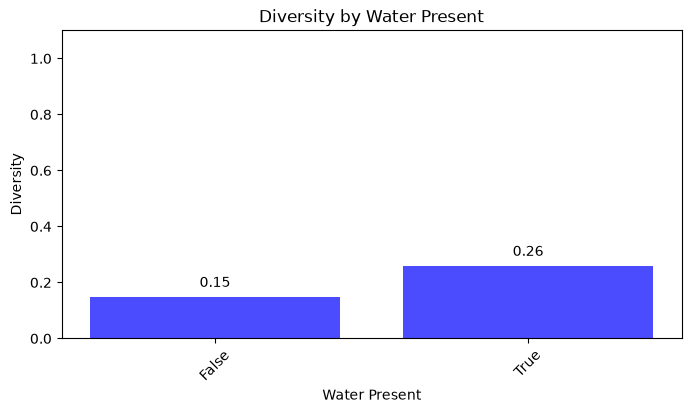

In [75]:
plot_single_bar_metric(water_present_metrics, x_column='water_present', metric='diversity', title='Diversity by Water Present', ylabel='Diversity', xlabel='Water Present')


### NDCG


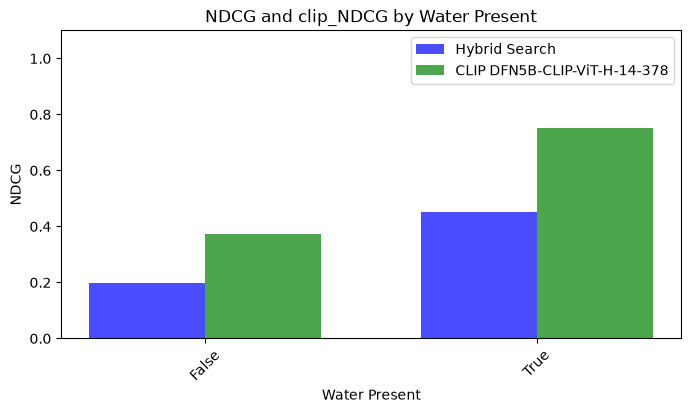

In [76]:
plot_rank_comparison(water_present_metrics, x_column='water_present', title='NDCG and clip_NDCG by Water Present', xlabel='Water Present')


### MRR


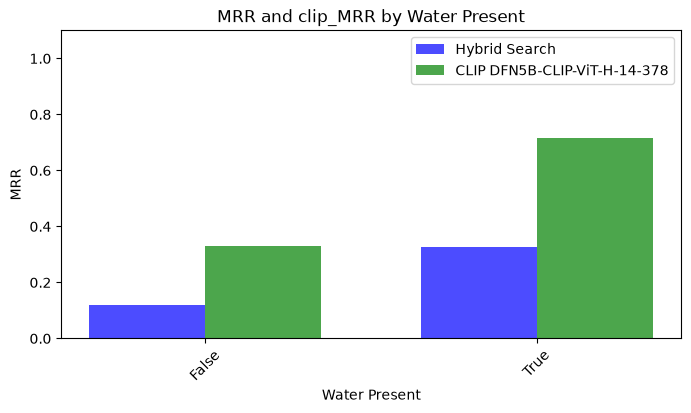

In [77]:
plot_rank_comparison(water_present_metrics, x_column='water_present', title='MRR and clip_MRR by Water Present', xlabel='Water Present', metric="MRR")


## Metrics based on Buildings Present

Now, we will evaluate queries based on **Buildings Present** (true vs false).


In [78]:
# Group by buildings_present and calculate the sum/mean of each metric
buildings_present_metrics = df.groupby('buildings_present').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

buildings_present_metrics['buildings_present'] = buildings_present_metrics['buildings_present'].map({True: 'True', False: 'False'})

#rename columns
buildings_present_metrics = buildings_present_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})
buildings_present_metrics = buildings_present_metrics.sort_values('buildings_present')

buildings_present_metrics


,buildings_present,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,1950,50,1900,41,1909,0.025641,0.021026,0.417521,0.461538,0.188304,0.358121,0.114852,0.322009,0.148782
1,True,1050,30,1020,26,1024,0.028571,0.024762,0.595238,0.595238,0.254829,0.460080,0.164562,0.413492,0.163217


### Accuracy


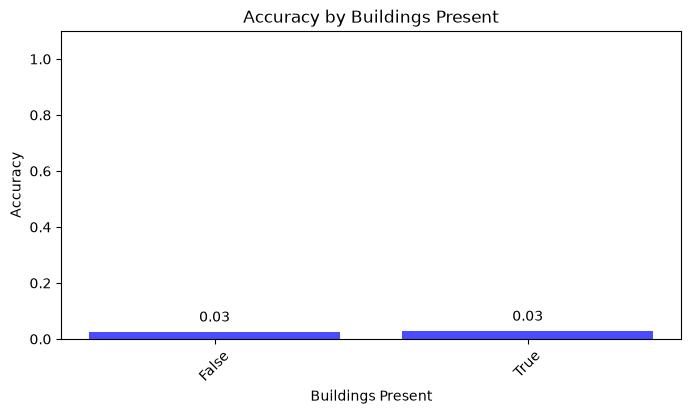

In [79]:
plot_single_bar_metric(buildings_present_metrics, x_column='buildings_present', metric='accuracy', title='Accuracy by Buildings Present', ylabel='Accuracy', xlabel='Buildings Present')


### Precision


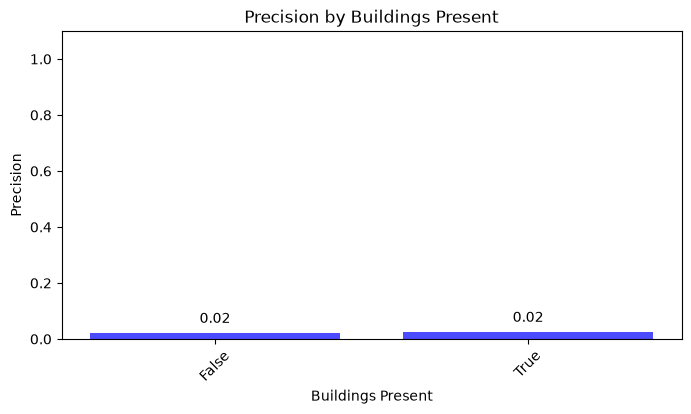

In [80]:
plot_single_bar_metric(buildings_present_metrics, x_column='buildings_present', metric='precision', title='Precision by Buildings Present', ylabel='Precision', xlabel='Buildings Present')


### Recall


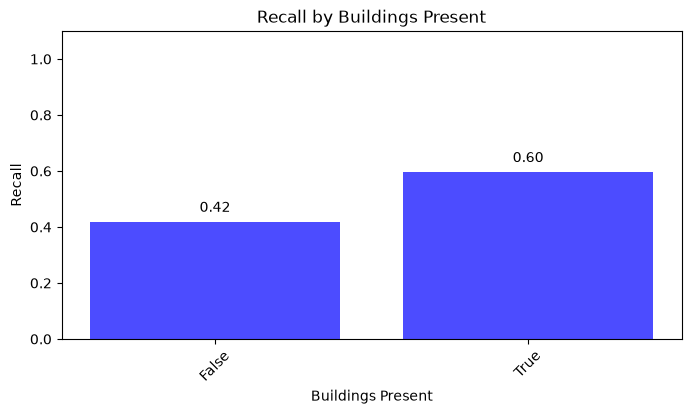

In [81]:
plot_single_bar_metric(buildings_present_metrics, x_column='buildings_present', metric='recall', title='Recall by Buildings Present', ylabel='Recall', xlabel='Buildings Present')


### Hit Rate


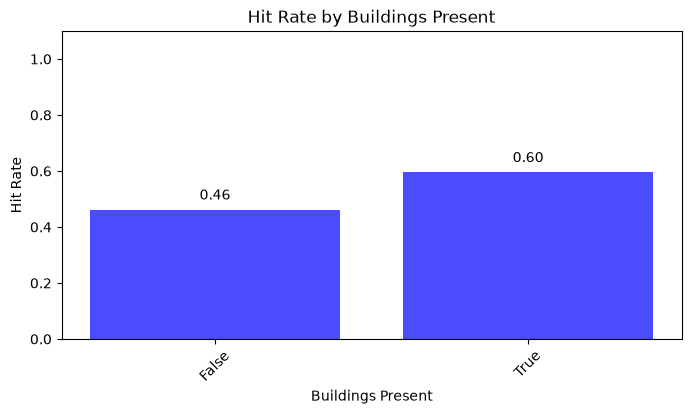

In [82]:
plot_single_bar_metric(buildings_present_metrics, x_column='buildings_present', metric='hit_rate', title='Hit Rate by Buildings Present', ylabel='Hit Rate', xlabel='Buildings Present')


### Diversity


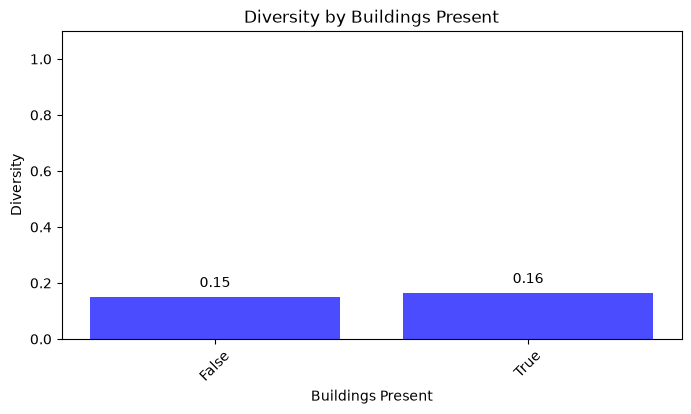

In [83]:
plot_single_bar_metric(buildings_present_metrics, x_column='buildings_present', metric='diversity', title='Diversity by Buildings Present', ylabel='Diversity', xlabel='Buildings Present')


### NDCG


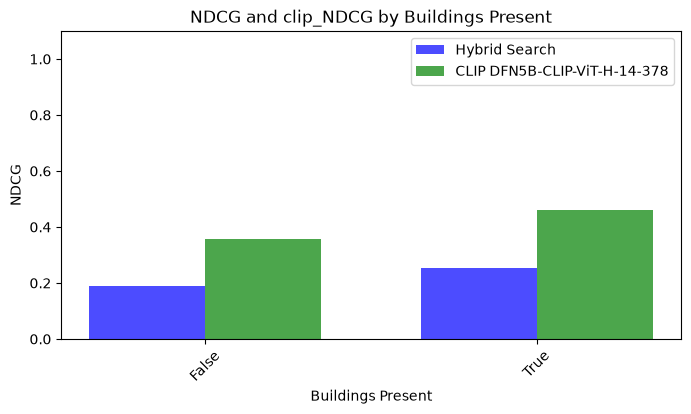

In [84]:
plot_rank_comparison(buildings_present_metrics, x_column='buildings_present', title='NDCG and clip_NDCG by Buildings Present', xlabel='Buildings Present')


### MRR


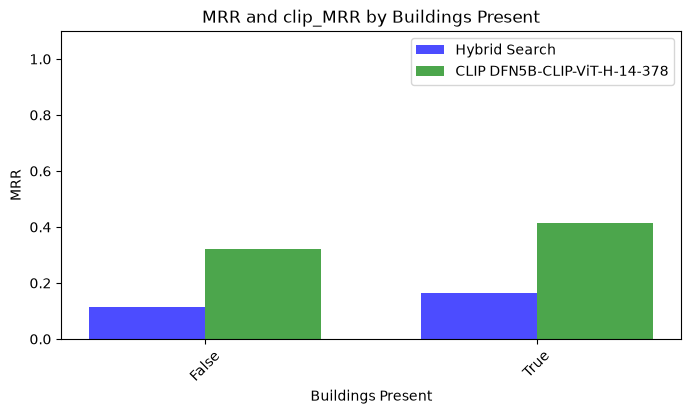

In [85]:
plot_rank_comparison(buildings_present_metrics, x_column='buildings_present', title='MRR and clip_MRR by Buildings Present', xlabel='Buildings Present', metric="MRR")


## Metrics based on Vehicle Present

Now, we will evaluate queries based on **Vehicle Present** (true vs false).


In [86]:
# Group by vehicle_present and calculate the sum/mean of each metric
vehicle_present_metrics = df.groupby('vehicle_present').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

vehicle_present_metrics['vehicle_present'] = vehicle_present_metrics['vehicle_present'].map({True: 'True', False: 'False'})


#rename columns
vehicle_present_metrics = vehicle_present_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})
vehicle_present_metrics = vehicle_present_metrics.sort_values('vehicle_present')

vehicle_present_metrics


,vehicle_present,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,2850,75,2775,62,2788,0.026316,0.021754,0.461111,0.491228,0.206883,0.377148,0.131609,0.337573,0.148239
1,True,150,5,145,5,145,0.033333,0.033333,0.833333,0.833333,0.300972,0.710310,0.144444,0.666667,0.260140


### Accuracy


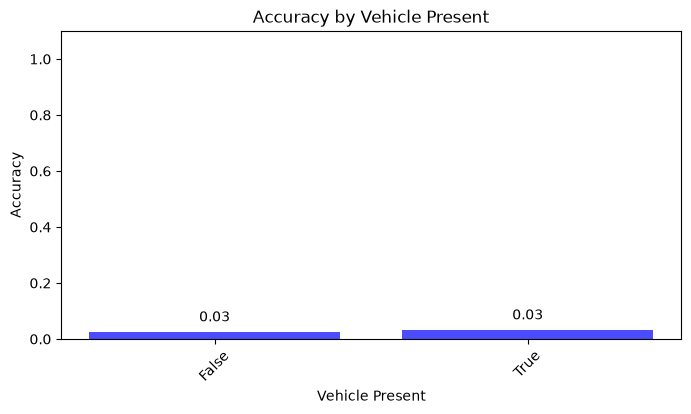

In [87]:
plot_single_bar_metric(vehicle_present_metrics, x_column='vehicle_present', metric='accuracy', title='Accuracy by Vehicle Present', ylabel='Accuracy', xlabel='Vehicle Present')


### Precision


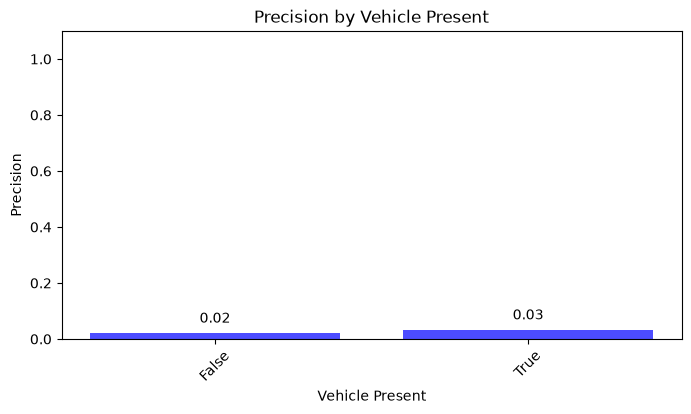

In [88]:
plot_single_bar_metric(vehicle_present_metrics, x_column='vehicle_present', metric='precision', title='Precision by Vehicle Present', ylabel='Precision', xlabel='Vehicle Present')


### Recall


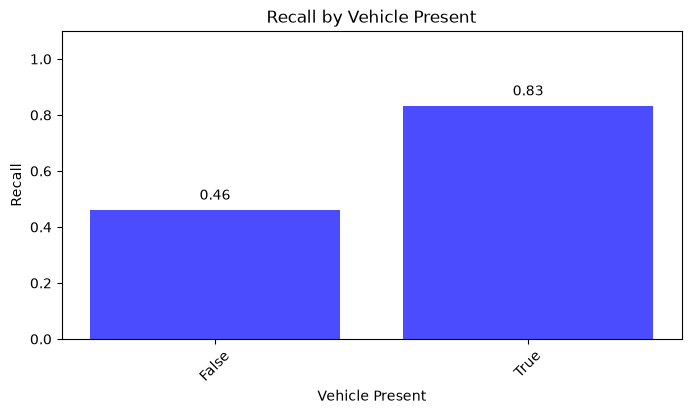

In [89]:
plot_single_bar_metric(vehicle_present_metrics, x_column='vehicle_present', metric='recall', title='Recall by Vehicle Present', ylabel='Recall', xlabel='Vehicle Present')


### Hit Rate


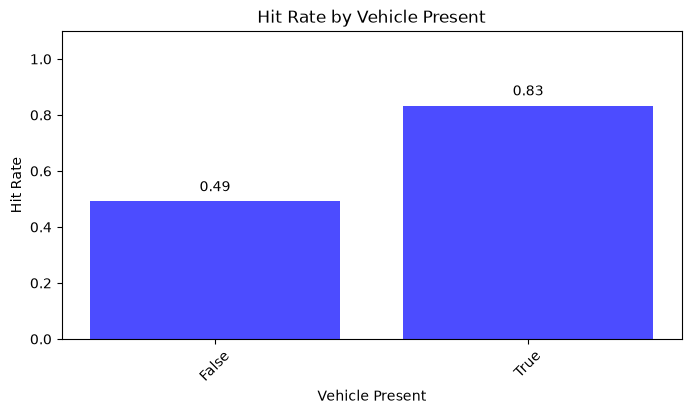

In [90]:
plot_single_bar_metric(vehicle_present_metrics, x_column='vehicle_present', metric='hit_rate', title='Hit Rate by Vehicle Present', ylabel='Hit Rate', xlabel='Vehicle Present')


### Diversity


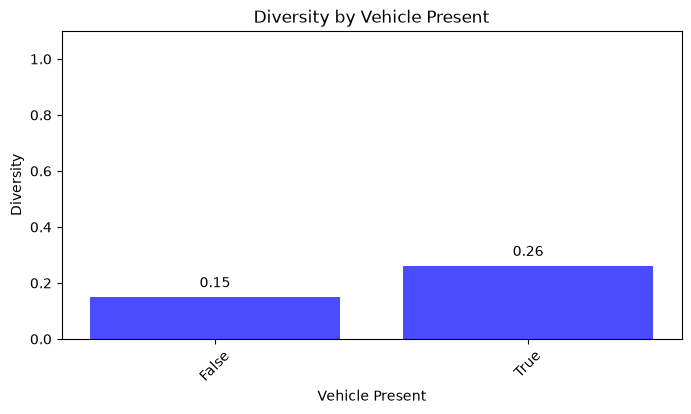

In [91]:
plot_single_bar_metric(vehicle_present_metrics, x_column='vehicle_present', metric='diversity', title='Diversity by Vehicle Present', ylabel='Diversity', xlabel='Vehicle Present')


### NDCG


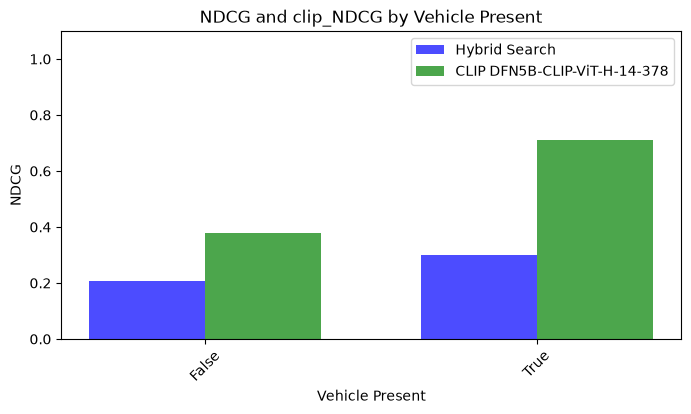

In [92]:
plot_rank_comparison(vehicle_present_metrics, x_column='vehicle_present', title='NDCG and clip_NDCG by Vehicle Present', xlabel='Vehicle Present')


### MRR


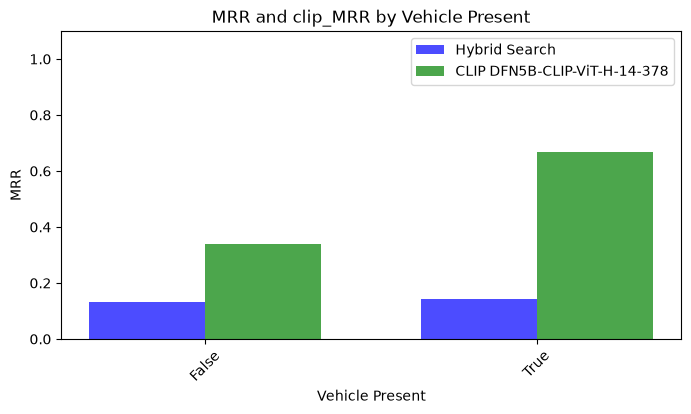

In [93]:
plot_rank_comparison(vehicle_present_metrics, x_column='vehicle_present', title='MRR and clip_MRR by Vehicle Present', xlabel='Vehicle Present', metric="MRR")


## Metrics based on Person Present

Now, we will evaluate queries based on **Person Present** (true vs false).


In [94]:
# Group by person_present and calculate the sum/mean of each metric
person_present_metrics = df.groupby('person_present').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

person_present_metrics['person_present'] = person_present_metrics['person_present'].map({True: 'True', False: 'False'})

#rename columns
person_present_metrics = person_present_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})
person_present_metrics = person_present_metrics.sort_values('person_present')

person_present_metrics


,person_present,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,3000,80,2920,67,2933,0.026667,0.022333,0.479722,0.508333,0.211588,0.393806,0.132251,0.354028,0.153834


### Accuracy


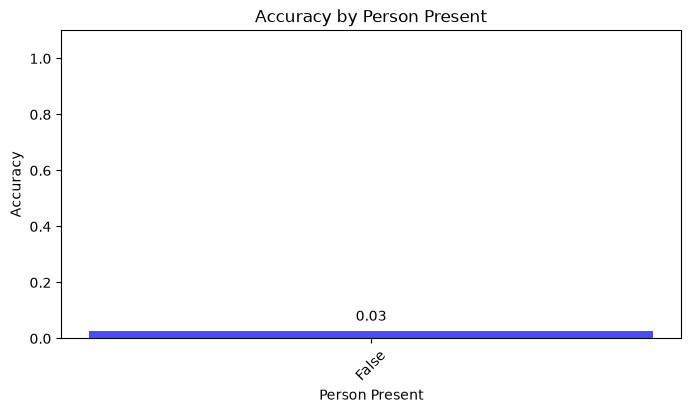

In [95]:
plot_single_bar_metric(person_present_metrics, x_column='person_present', metric='accuracy', title='Accuracy by Person Present', ylabel='Accuracy', xlabel='Person Present')


### Precision


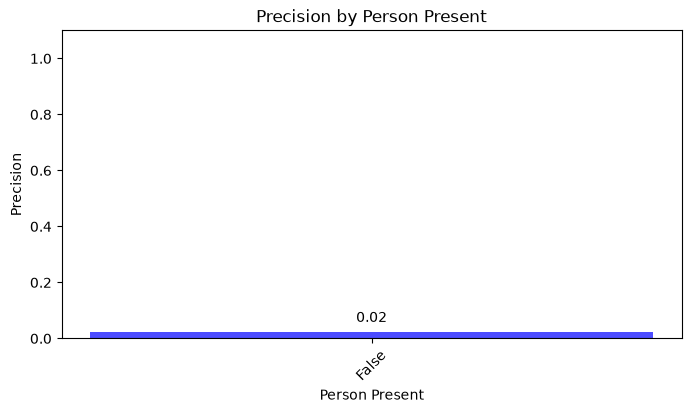

In [96]:
plot_single_bar_metric(person_present_metrics, x_column='person_present', metric='precision', title='Precision by Person Present', ylabel='Precision', xlabel='Person Present')


### Recall


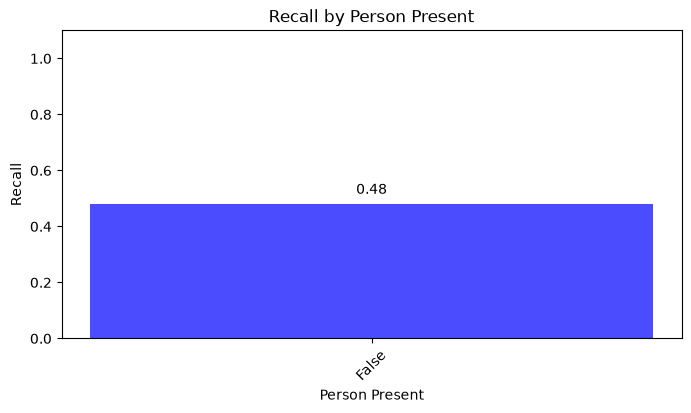

In [97]:
plot_single_bar_metric(person_present_metrics, x_column='person_present', metric='recall', title='Recall by Person Present', ylabel='Recall', xlabel='Person Present')


### Hit Rate


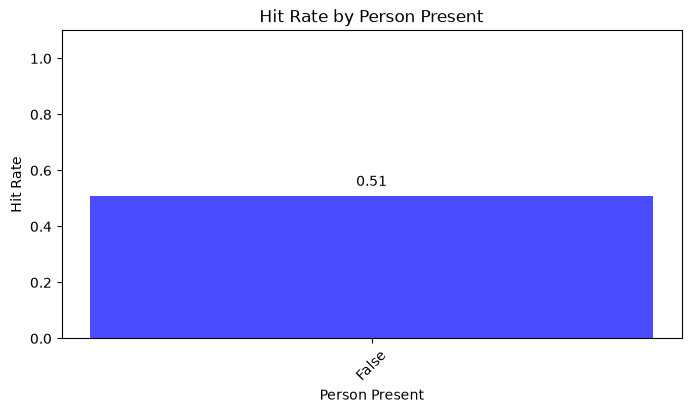

In [98]:
plot_single_bar_metric(person_present_metrics, x_column='person_present', metric='hit_rate', title='Hit Rate by Person Present', ylabel='Hit Rate', xlabel='Person Present')


### Diversity


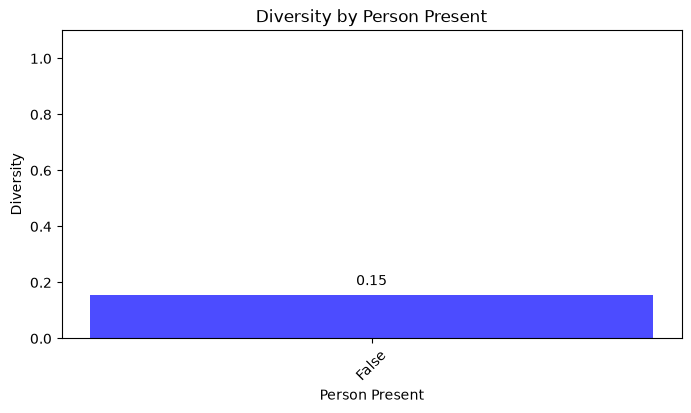

In [99]:
plot_single_bar_metric(person_present_metrics, x_column='person_present', metric='diversity', title='Diversity by Person Present', ylabel='Diversity', xlabel='Person Present')


### NDCG


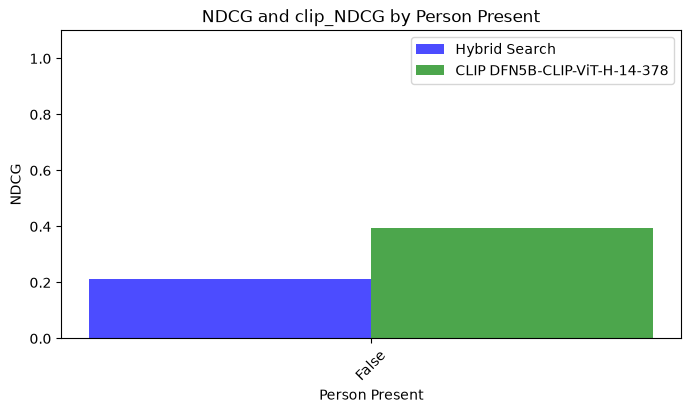

In [100]:
plot_rank_comparison(person_present_metrics, x_column='person_present', title='NDCG and clip_NDCG by Person Present', xlabel='Person Present')


### MRR


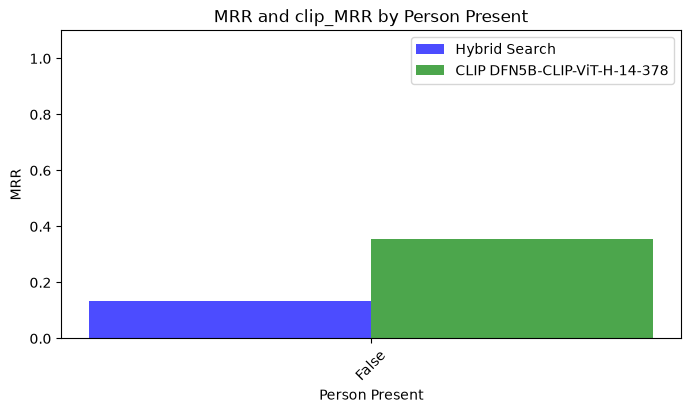

In [101]:
plot_rank_comparison(person_present_metrics, x_column='person_present', title='MRR and clip_MRR by Person Present', xlabel='Person Present', metric="MRR")


## Metrics based on Animal Present

Now, we will evaluate queries based on **Animal Present** (true vs false).


In [102]:
# Group by animal_present and calculate the sum/mean of each metric
animal_present_metrics = df.groupby('animal_present').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

animal_present_metrics['animal_present'] = animal_present_metrics['animal_present'].map({True: 'True', False: 'False'})

#rename columns
animal_present_metrics = animal_present_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})
animal_present_metrics = animal_present_metrics.sort_values('animal_present')

animal_present_metrics


,animal_present,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,3000,80,2920,67,2933,0.026667,0.022333,0.479722,0.508333,0.211588,0.393806,0.132251,0.354028,0.153834


### Accuracy


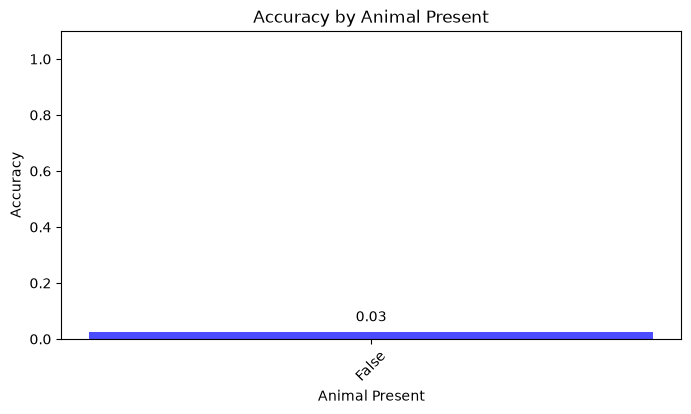

In [103]:
plot_single_bar_metric(animal_present_metrics, x_column='animal_present', metric='accuracy', title='Accuracy by Animal Present', ylabel='Accuracy', xlabel='Animal Present')


### Precision


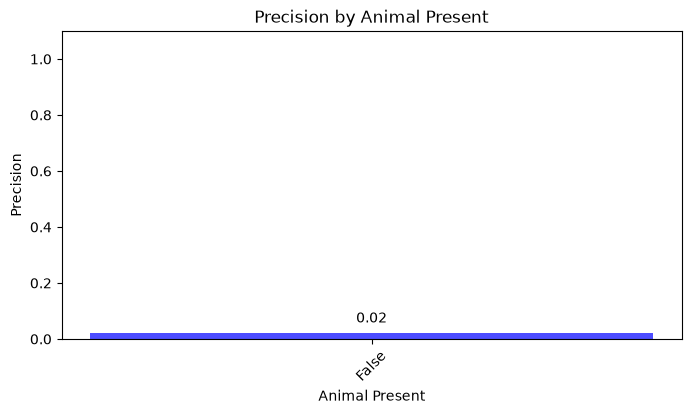

In [104]:
plot_single_bar_metric(animal_present_metrics, x_column='animal_present', metric='precision', title='Precision by Animal Present', ylabel='Precision', xlabel='Animal Present')


### Recall


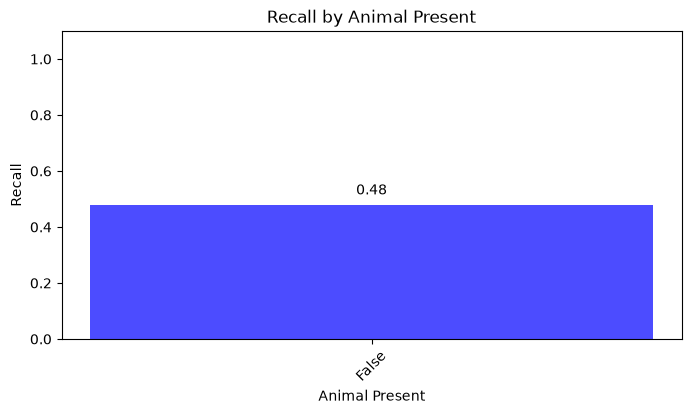

In [105]:
plot_single_bar_metric(animal_present_metrics, x_column='animal_present', metric='recall', title='Recall by Animal Present', ylabel='Recall', xlabel='Animal Present')


### Hit Rate


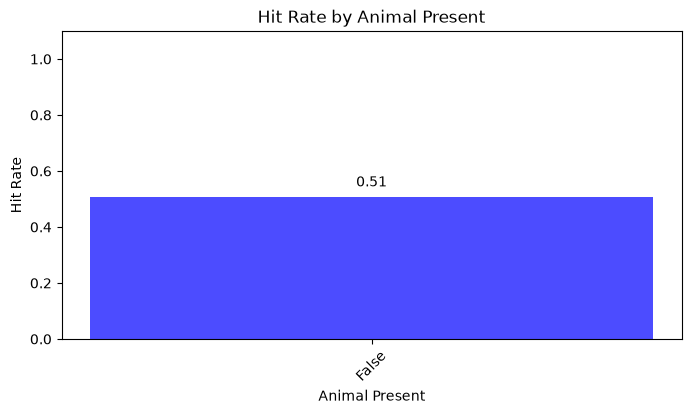

In [106]:
plot_single_bar_metric(animal_present_metrics, x_column='animal_present', metric='hit_rate', title='Hit Rate by Animal Present', ylabel='Hit Rate', xlabel='Animal Present')


### Diversity


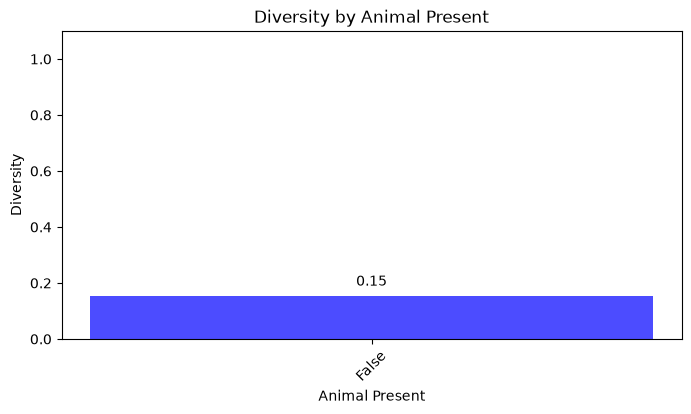

In [107]:
plot_single_bar_metric(animal_present_metrics, x_column='animal_present', metric='diversity', title='Diversity by Animal Present', ylabel='Diversity', xlabel='Animal Present')


### NDCG


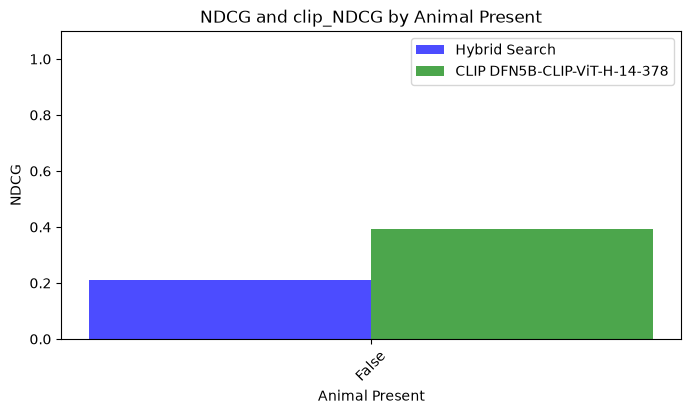

In [108]:
plot_rank_comparison(animal_present_metrics, x_column='animal_present', title='NDCG and clip_NDCG by Animal Present', xlabel='Animal Present')


### MRR


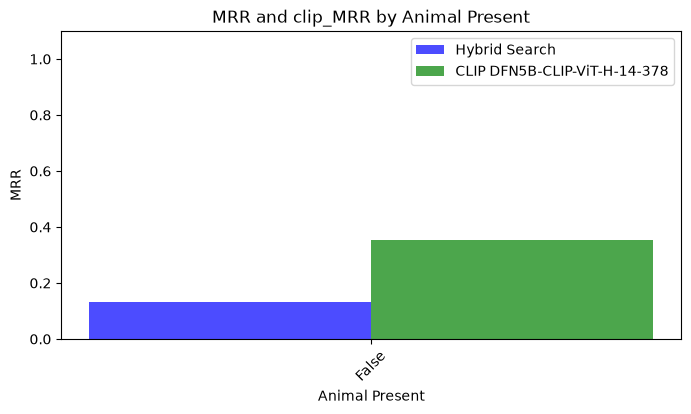

In [109]:
plot_rank_comparison(animal_present_metrics, x_column='animal_present', title='MRR and clip_MRR by Animal Present', xlabel='Animal Present', metric="MRR")


## Metrics based on Night Scene

Now, we will evaluate queries based on **Night Scene** (true vs false).


In [110]:
# Group by night_scene and calculate the sum/mean of each metric
night_scene_metrics = df.groupby('night_scene').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

night_scene_metrics['night_scene'] = night_scene_metrics['night_scene'].map({True: 'True', False: 'False'})

#rename columns
night_scene_metrics = night_scene_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})
night_scene_metrics = night_scene_metrics.sort_values('night_scene')

night_scene_metrics


,night_scene,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,1975,57,1918,51,1924,0.028861,0.025823,0.549367,0.582278,0.239706,0.477270,0.146944,0.440928,0.154186
1,True,1025,23,1002,16,1009,0.022439,0.015610,0.345528,0.365854,0.157408,0.232987,0.103939,0.186585,0.153157


### Accuracy


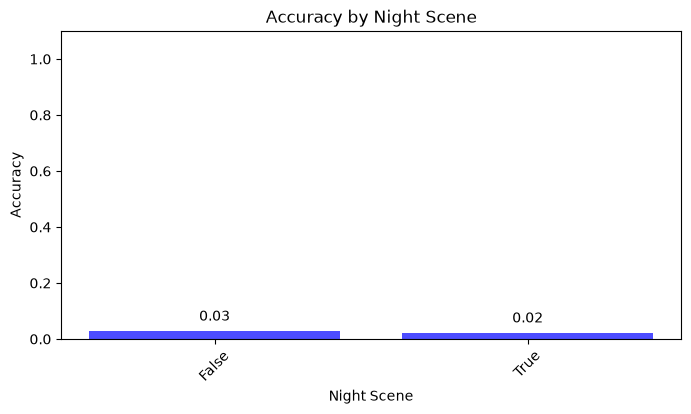

In [111]:
plot_single_bar_metric(night_scene_metrics, x_column='night_scene', metric='accuracy', title='Accuracy by Night Scene', ylabel='Accuracy', xlabel='Night Scene')


### Precision


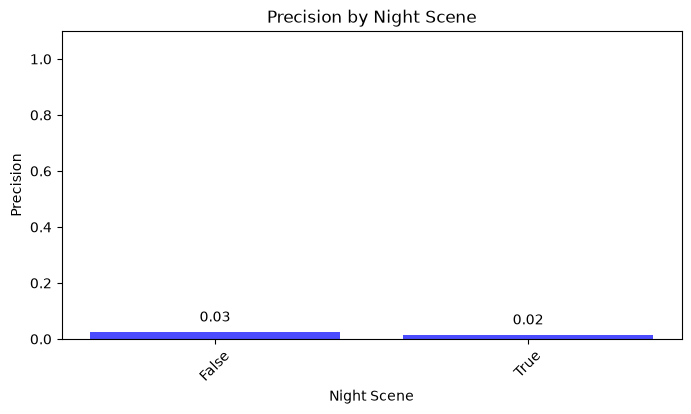

In [112]:
plot_single_bar_metric(night_scene_metrics, x_column='night_scene', metric='precision', title='Precision by Night Scene', ylabel='Precision', xlabel='Night Scene')


### Recall


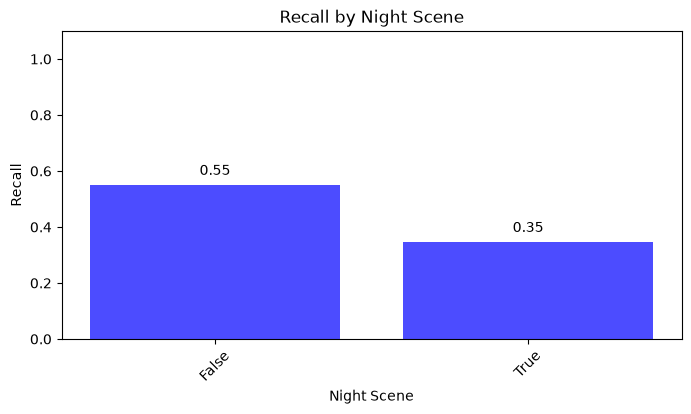

In [113]:
plot_single_bar_metric(night_scene_metrics, x_column='night_scene', metric='recall', title='Recall by Night Scene', ylabel='Recall', xlabel='Night Scene')


### Hit Rate


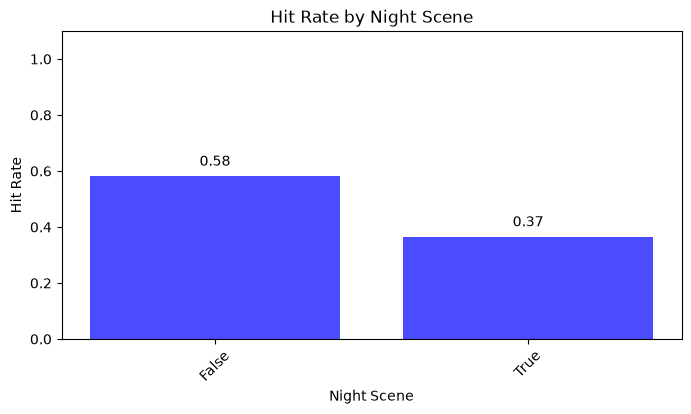

In [114]:
plot_single_bar_metric(night_scene_metrics, x_column='night_scene', metric='hit_rate', title='Hit Rate by Night Scene', ylabel='Hit Rate', xlabel='Night Scene')


### Diversity


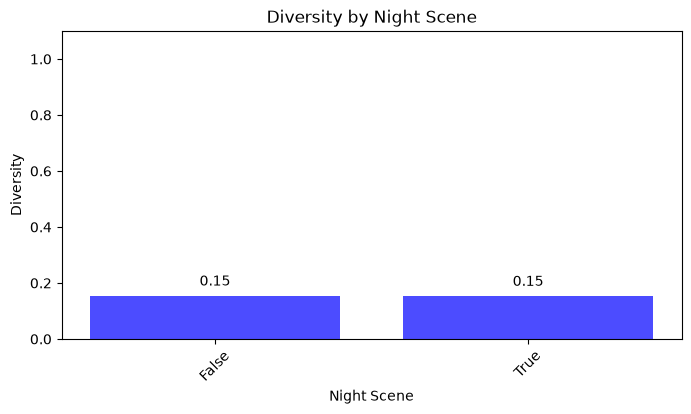

In [115]:
plot_single_bar_metric(night_scene_metrics, x_column='night_scene', metric='diversity', title='Diversity by Night Scene', ylabel='Diversity', xlabel='Night Scene')


### NDCG


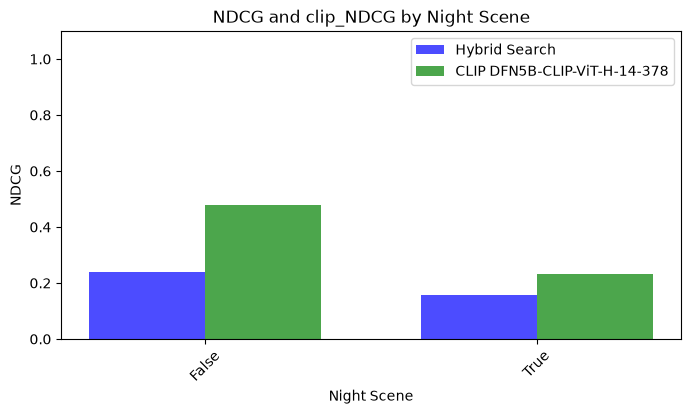

In [116]:
plot_rank_comparison(night_scene_metrics, x_column='night_scene', title='NDCG and clip_NDCG by Night Scene', xlabel='Night Scene')


### MRR


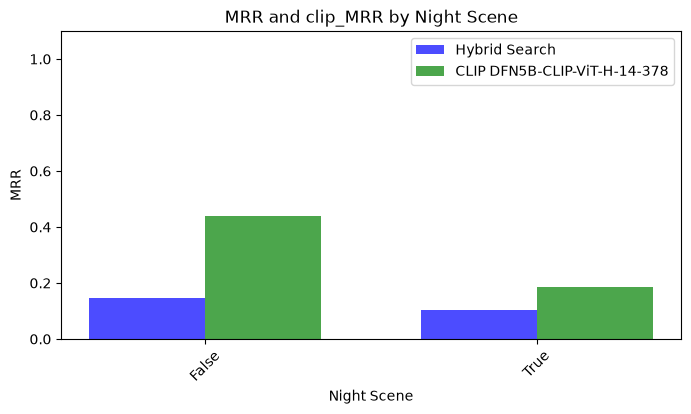

In [117]:
plot_rank_comparison(night_scene_metrics, x_column='night_scene', title='MRR and clip_MRR by Night Scene', xlabel='Night Scene', metric="MRR")


## Metrics based on Precipitation Visible

Now, we will evaluate queries based on **Precipitation Visible** (true vs false).


In [118]:
# Group by precipitation_visible and calculate the sum/mean of each metric
precipitation_visible_metrics = df.groupby('precipitation_visible').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

precipitation_visible_metrics['precipitation_visible'] = precipitation_visible_metrics['precipitation_visible'].map({True: 'True', False: 'False'})

#rename columns
precipitation_visible_metrics = precipitation_visible_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})
precipitation_visible_metrics = precipitation_visible_metrics.sort_values('precipitation_visible')

precipitation_visible_metrics


,precipitation_visible,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,2900,78,2822,65,2835,0.026897,0.022414,0.479023,0.508621,0.213693,0.394455,0.134728,0.354741,0.153540
1,True,100,2,98,2,98,0.020000,0.020000,0.500000,0.500000,0.150548,0.375000,0.060417,0.333333,0.162381


### Accuracy


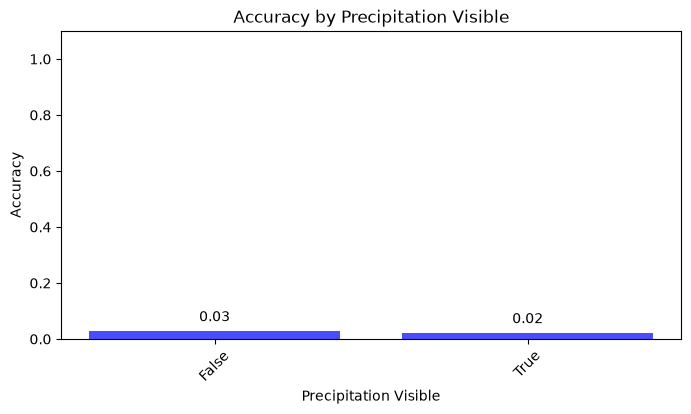

In [119]:
plot_single_bar_metric(precipitation_visible_metrics, x_column='precipitation_visible', metric='accuracy', title='Accuracy by Precipitation Visible', ylabel='Accuracy', xlabel='Precipitation Visible')


### Precision


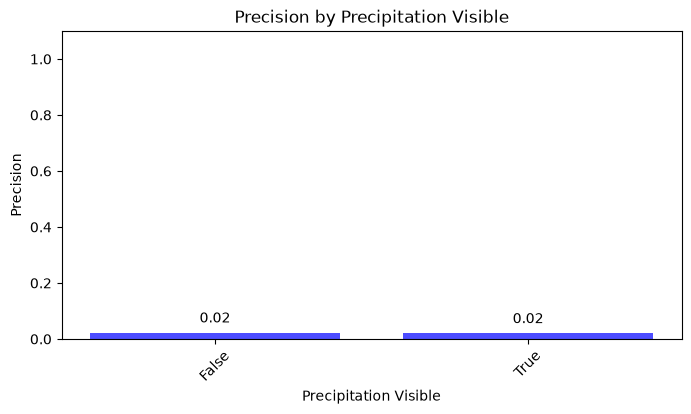

In [120]:
plot_single_bar_metric(precipitation_visible_metrics, x_column='precipitation_visible', metric='precision', title='Precision by Precipitation Visible', ylabel='Precision', xlabel='Precipitation Visible')


### Recall


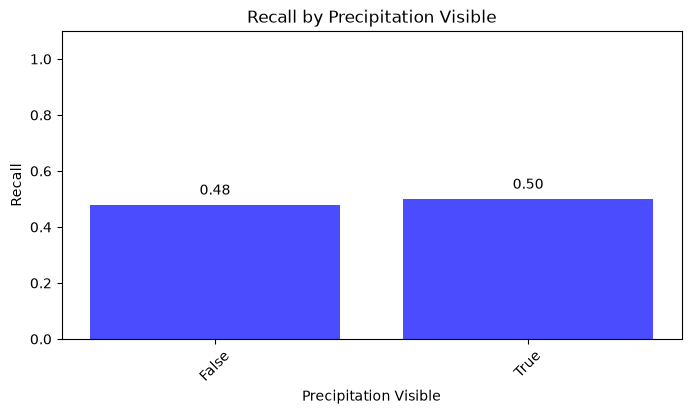

In [121]:
plot_single_bar_metric(precipitation_visible_metrics, x_column='precipitation_visible', metric='recall', title='Recall by Precipitation Visible', ylabel='Recall', xlabel='Precipitation Visible')


### Hit Rate


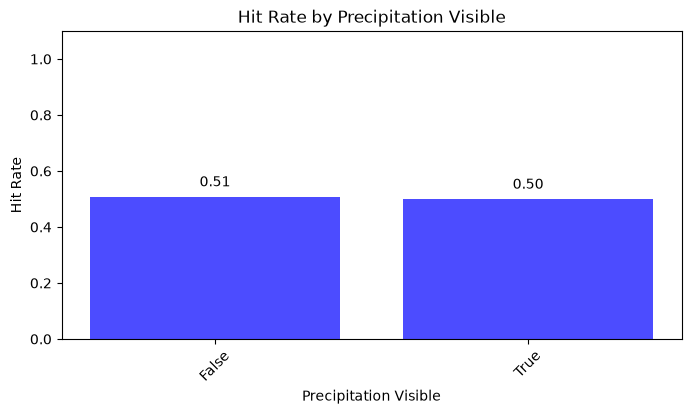

In [122]:
plot_single_bar_metric(precipitation_visible_metrics, x_column='precipitation_visible', metric='hit_rate', title='Hit Rate by Precipitation Visible', ylabel='Hit Rate', xlabel='Precipitation Visible')


### Diversity


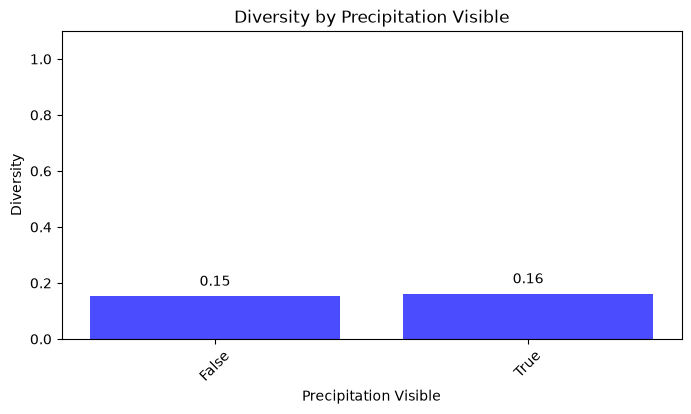

In [123]:
plot_single_bar_metric(precipitation_visible_metrics, x_column='precipitation_visible', metric='diversity', title='Diversity by Precipitation Visible', ylabel='Diversity', xlabel='Precipitation Visible')


### NDCG


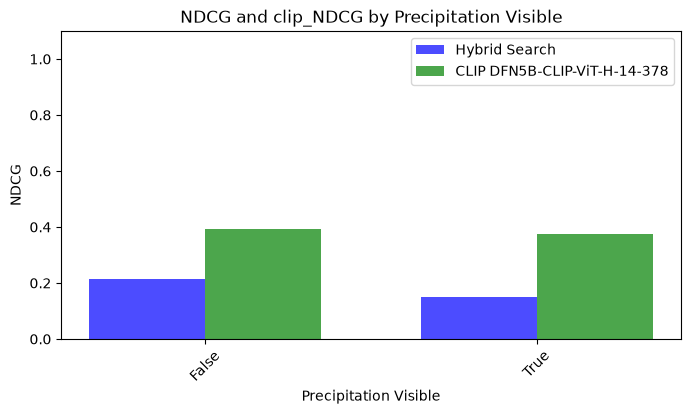

In [124]:
plot_rank_comparison(precipitation_visible_metrics, x_column='precipitation_visible', title='NDCG and clip_NDCG by Precipitation Visible', xlabel='Precipitation Visible')


### MRR


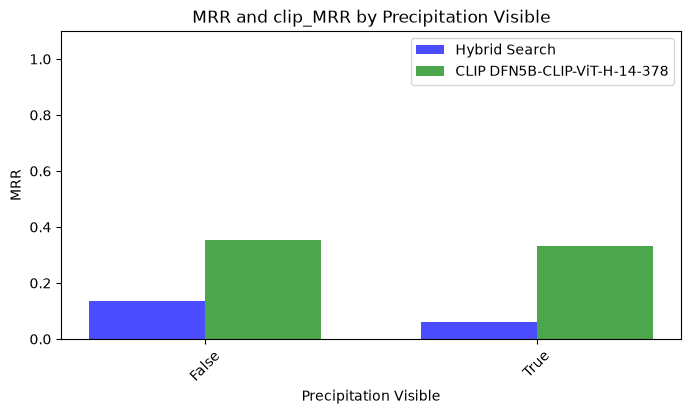

In [125]:
plot_rank_comparison(precipitation_visible_metrics, x_column='precipitation_visible', title='MRR and clip_MRR by Precipitation Visible', xlabel='Precipitation Visible', metric="MRR")


## Metrics based on Multiple Objects

Now, we will evaluate queries based on **Multiple Objects** (true vs false).


In [126]:
# Group by multiple_objects and calculate the sum/mean of each metric
multiple_objects_metrics = df.groupby('multiple_objects').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

multiple_objects_metrics['multiple_objects'] = multiple_objects_metrics['multiple_objects'].map({True: 'True', False: 'False'})

#rename columns
multiple_objects_metrics = multiple_objects_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})
multiple_objects_metrics = multiple_objects_metrics.sort_values('multiple_objects')

multiple_objects_metrics


,multiple_objects,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,250,4,246,3,247,0.016000,0.012000,0.166667,0.200000,0.067638,0.132436,0.027778,0.100000,0.180833
1,True,2750,76,2674,64,2686,0.027636,0.023273,0.508182,0.536364,0.224674,0.417567,0.141748,0.377121,0.151380


### Accuracy


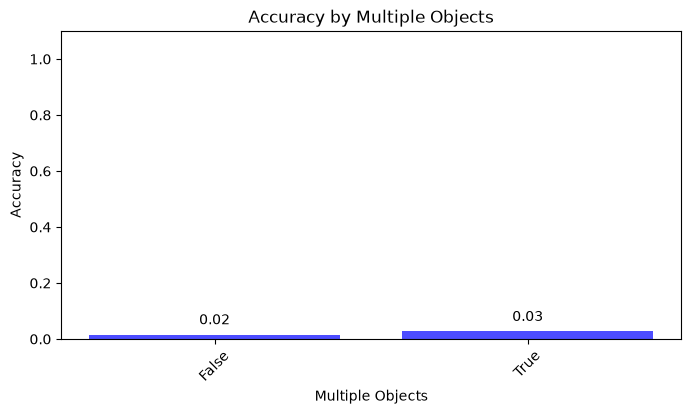

In [127]:
plot_single_bar_metric(multiple_objects_metrics, x_column='multiple_objects', metric='accuracy', title='Accuracy by Multiple Objects', ylabel='Accuracy', xlabel='Multiple Objects')


### Precision


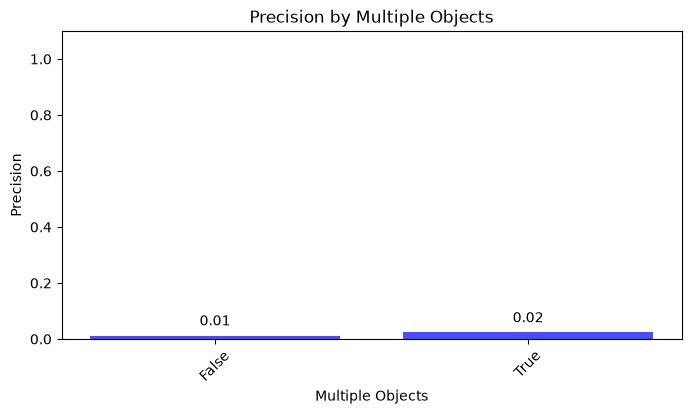

In [128]:
plot_single_bar_metric(multiple_objects_metrics, x_column='multiple_objects', metric='precision', title='Precision by Multiple Objects', ylabel='Precision', xlabel='Multiple Objects')


### Recall


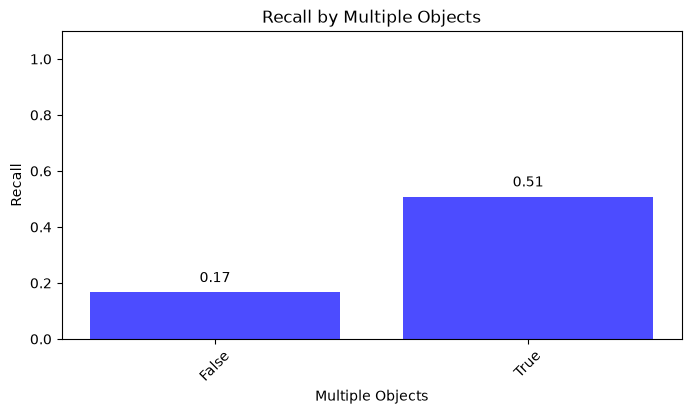

In [129]:
plot_single_bar_metric(multiple_objects_metrics, x_column='multiple_objects', metric='recall', title='Recall by Multiple Objects', ylabel='Recall', xlabel='Multiple Objects')


### Hit Rate


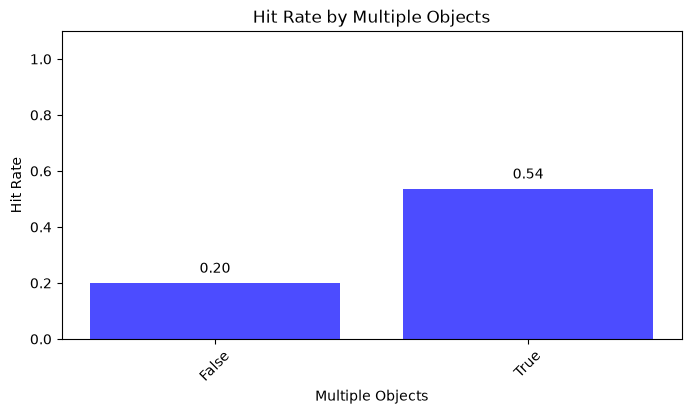

In [130]:
plot_single_bar_metric(multiple_objects_metrics, x_column='multiple_objects', metric='hit_rate', title='Hit Rate by Multiple Objects', ylabel='Hit Rate', xlabel='Multiple Objects')


### Diversity


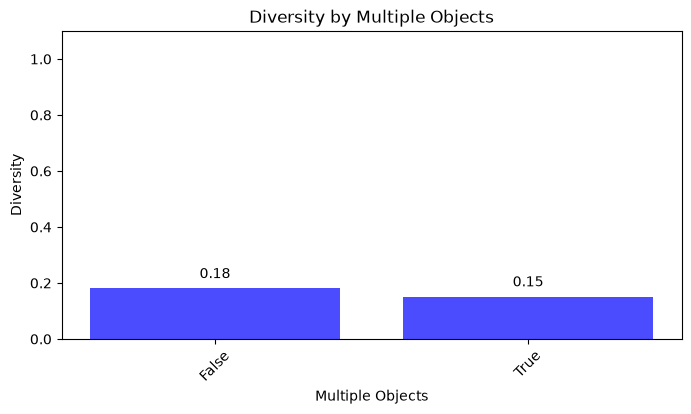

In [131]:
plot_single_bar_metric(multiple_objects_metrics, x_column='multiple_objects', metric='diversity', title='Diversity by Multiple Objects', ylabel='Diversity', xlabel='Multiple Objects')


### NDCG


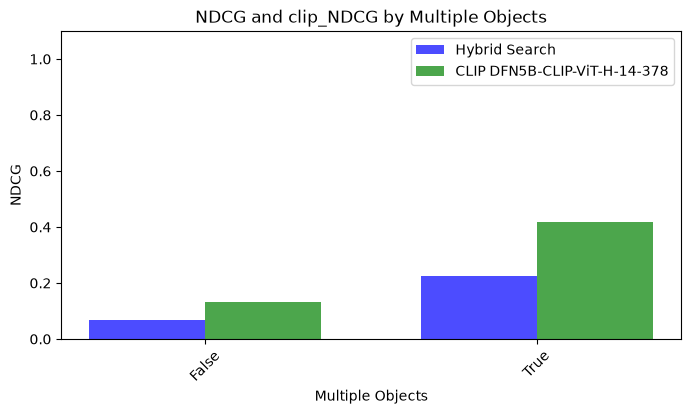

In [132]:
plot_rank_comparison(multiple_objects_metrics, x_column='multiple_objects', title='NDCG and clip_NDCG by Multiple Objects', xlabel='Multiple Objects')


### MRR


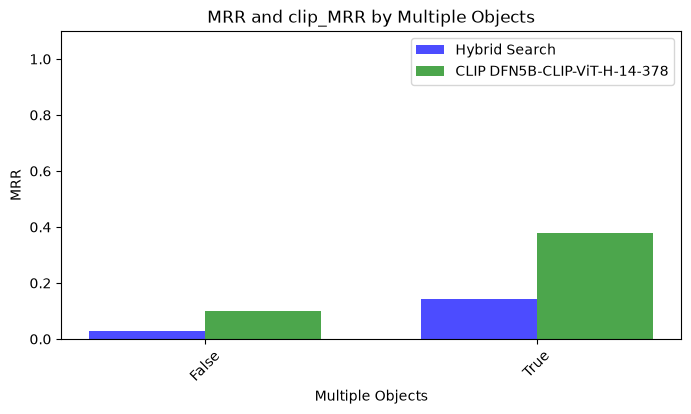

In [133]:
plot_rank_comparison(multiple_objects_metrics, x_column='multiple_objects', title='MRR and clip_MRR by Multiple Objects', xlabel='Multiple Objects', metric="MRR")


## Metrics based on Viewpoint & Precipitation Visible

Here we will group by Precipitation Visible and Viewpoint and calculate the sum/mean of each metric to see how the system performs under different Precipitation Visible and Viewpoint conditions.

>NOTE: due to the large number of combinations you can group by, we will not show all of them. Use this section as a guide if you want to break down the data by different combinations of the metadata.

In [134]:
# Group
view_preci_metrics = df.groupby(['viewpoint', 'precipitation_visible']).agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()
view_preci_metrics['precipitation_visible'] = view_preci_metrics['precipitation_visible'].map({True: 'True', False: 'False'})

#rename columns
view_preci_metrics = view_preci_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})

# set up graph variables
metrics = view_preci_metrics
x_column = 'viewpoint'
group_column = 'precipitation_visible'
title = 'Viewpoint & Precipitation Visible'
colors = {
    "True": "green",
    "False": "red",
}

metrics

,viewpoint,precipitation_visible,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,duo_view,False,50,3,47,1,49,0.060000,0.020000,0.500000,0.500000,0.117704,0.250000,0.027778,0.166667,0.200229
1,fisheye_sky,False,625,16,609,14,611,0.025600,0.022400,0.480000,0.480000,0.176159,0.386986,0.092609,0.353333,0.146656
2,fisheye_sky,True,75,1,74,1,74,0.013333,0.013333,0.333333,0.333333,0.128951,0.333333,0.066667,0.333333,0.141858
3,ground_horizontal,False,1900,49,1851,42,1858,0.025789,0.022105,0.478947,0.513158,0.227386,0.396406,0.151574,0.357237,0.152506
4,ground_horizontal,True,25,1,24,1,24,0.040000,0.040000,1.000000,1.000000,0.215338,0.500000,0.041667,0.333333,0.223949
5,ground_upward,False,150,3,147,3,147,0.020000,0.020000,0.500000,0.500000,0.288618,0.355155,0.226852,0.305556,0.198876
6,oblique,False,125,4,121,3,122,0.032000,0.024000,0.500000,0.600000,0.152112,0.526186,0.042051,0.500000,0.115917
7,unknown,False,50,3,47,2,48,0.060000,0.040000,0.333333,0.500000,0.187674,0.346713,0.083333,0.250000,0.190221


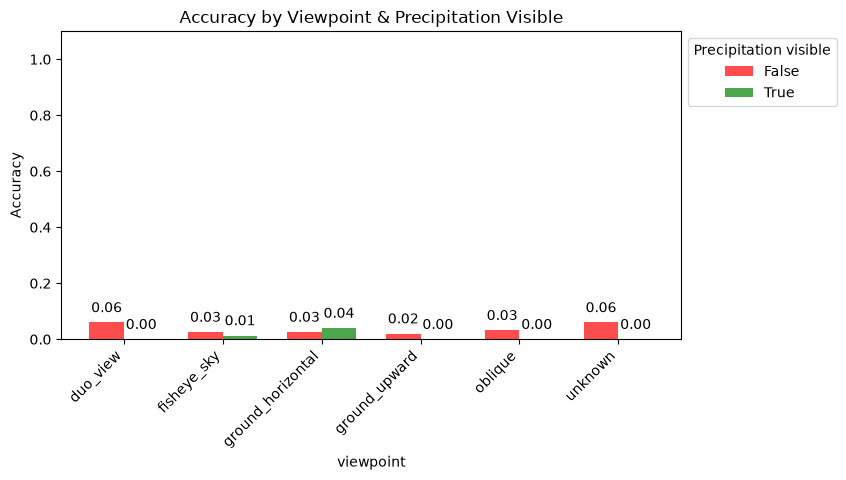

In [135]:
plot_grouped_bar_by_columns(
    metrics, 
    x_column=x_column, 
    color_column=group_column, 
    metric='accuracy', 
    color_map=colors, 
    ylabel="Accuracy", 
    xlabel=x_column, 
    title=f"Accuracy by {title}",
)

### Precision

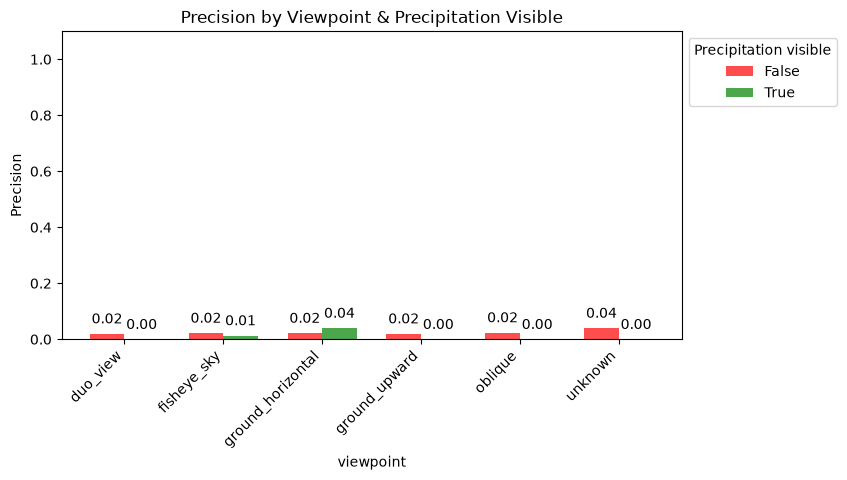

In [136]:
plot_grouped_bar_by_columns(
    metrics, 
    x_column=x_column, 
    color_column=group_column, 
    metric='precision', 
    color_map=colors, 
    ylabel="Precision", 
    xlabel=x_column, 
    title=f"Precision by {title}",
)

### Recall

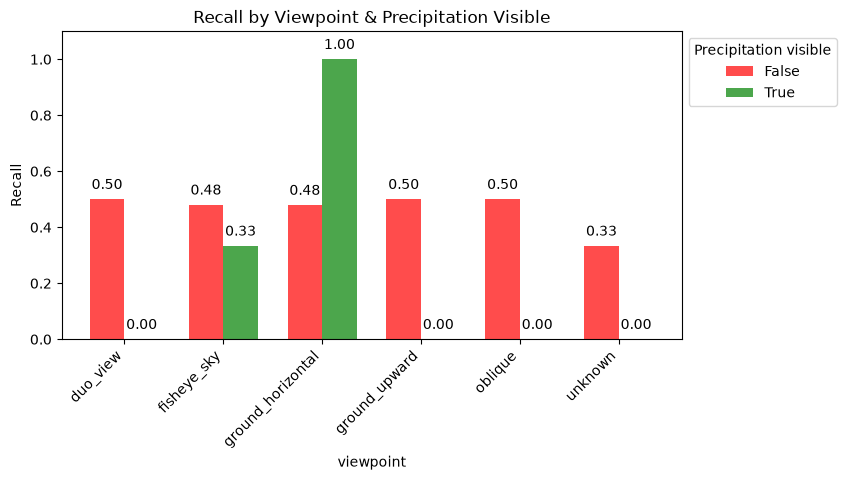

In [137]:
plot_grouped_bar_by_columns(
    metrics, 
    x_column=x_column, 
    color_column=group_column, 
    metric='recall', 
    color_map=colors,
    ylabel="Recall", 
    xlabel=x_column, 
    title=f"Recall by {title}",
)


### Hit Rate

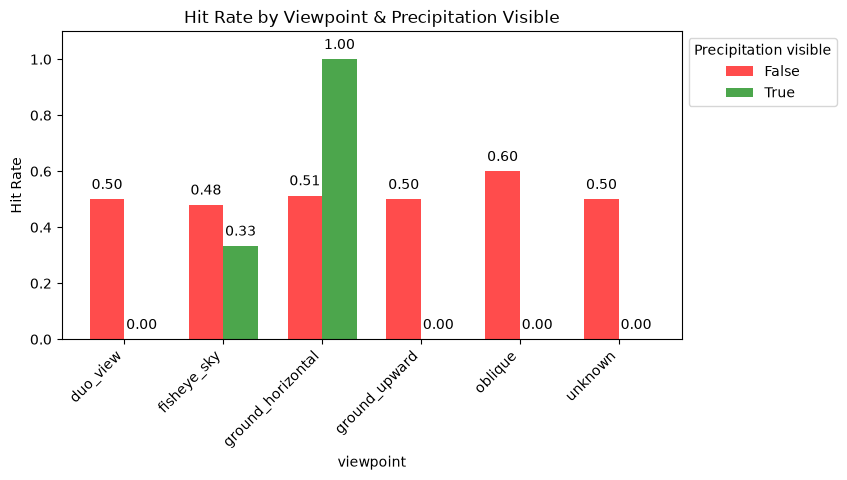

In [138]:
plot_grouped_bar_by_columns(
    metrics, 
    x_column=x_column, 
    color_column=group_column, 
    metric='hit_rate', 
    color_map=colors,
    ylabel="Hit Rate", 
    xlabel=x_column, 
    title=f"Hit Rate by {title}",
)

### Diversity

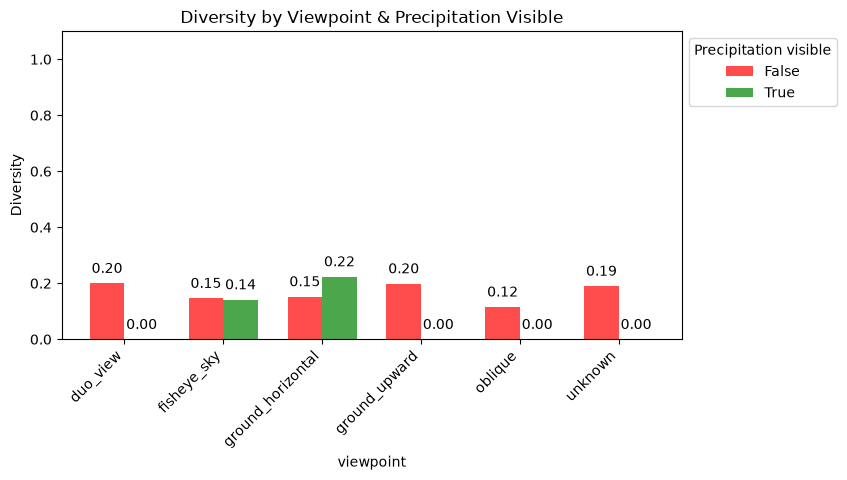

In [139]:
plot_grouped_bar_by_columns(
    metrics, 
    x_column=x_column, 
    color_column=group_column, 
    metric='diversity', 
    color_map=colors,
    ylabel="Diversity", 
    xlabel=x_column, 
    title=f"Diversity by {title}",
)

### NDCG

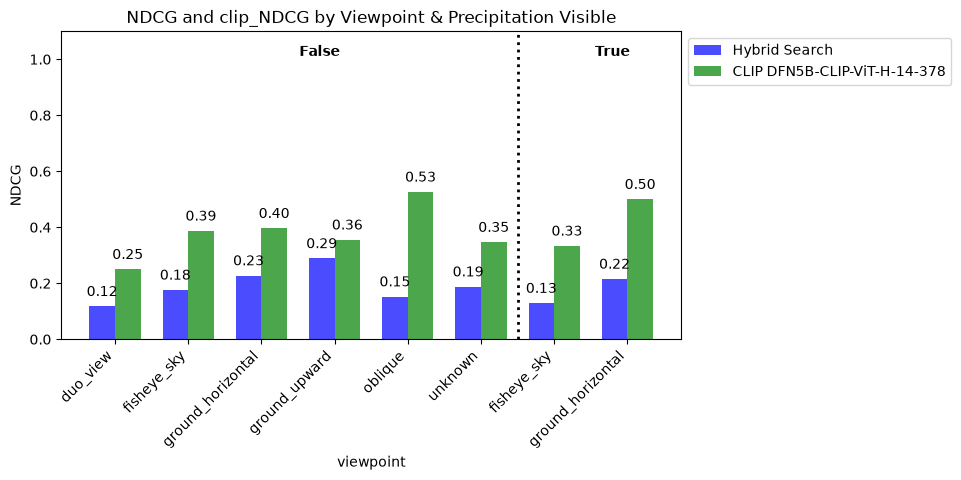

In [140]:
# Sort by group_column so group dividers and labels are correct
_ndcg_df = metrics.sort_values(group_column).reset_index(drop=True)
plot_multi_rank_comparison(
    _ndcg_df,
    x_column=x_column,
    group_column=group_column,
    title=f"NDCG and clip_NDCG by {title}",
    xlabel=x_column,
)


### MRR

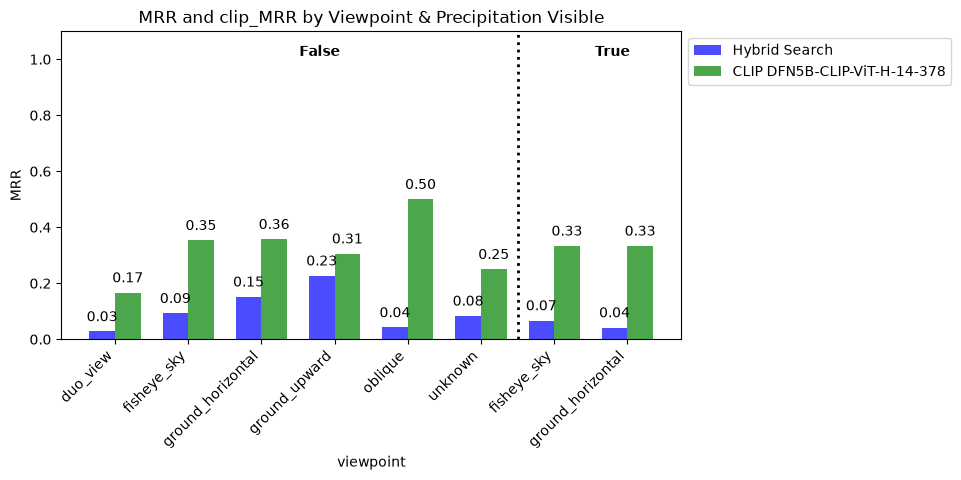

In [141]:
_mrr_df = metrics.sort_values(group_column).reset_index(drop=True)
plot_multi_rank_comparison(_mrr_df, x_column=x_column, group_column=group_column, title=f'MRR and clip_MRR by {title}', xlabel=x_column, metric="MRR")

## Insights & Conclusion

**System Differences**

Three runs on the same 120 queries × 25 results (3,000 images):

- **Baseline (b)** — `openai/clip-vit-base-patch32`, no caption generation, image-only indexing (`embed_image=true`, `embed_caption=false`), vector-only retrieval (`enable_bm25=false`, `alpha=1.0`).
- **Vector Search Only (a)** — `DFN5B-CLIP-ViT-H-14-378` with Gemma captions, fused image + caption embeddings (`embed_image=true`, `embed_caption=true`, `index_clip_alpha=0.7`), but **keyword search disabled** (`enable_bm25=false`, `alpha=1.0`)—pure CLIP vector retrieval with caption reranking.
- **v12** — Same stack as (a) plus **hybrid BM25 keyword search** (`enable_bm25=true`, `alpha=0.4`, `clip_alpha=0.7`).

This isolates how much SageBench retrieval comes from keyword/BM25 search on top of production CLIP + caption fusion. SageBench queries pair natural-language questions with **Sage deployment metadata** (vsn, zone, host, job, plugin, etc.).

---

**Overall Metrics Comparison**

| Metric                   | Baseline (b) | Vector Search Only (a) |  v12  | Difference (a - b) | Difference (v12 - a) |
| ------------------------ | --- | --- | --- | --- | --- |
| **Total Images**         | 3,000 | 3,000 | 3,000 | 0 | 0 |
| **Correctly Returned**   | 56 | 80 | 79 | +24 | −1 |
| **Incorrectly Returned** | 2,944 | 2,920 | 2,921 | −24 | +1 |
| **Relevant Images**      | 42 | 67 | 68 | +25 | +1 |
| **Accuracy**             | 0.0187 | 0.0267 | 0.0263 | +0.0080 | −0.0003 |
| **Precision**            | 0.0140 | 0.0223 | 0.0227 | +0.0083 | +0.0003 |
| **Recall**               | 0.3038 | 0.4797 | 0.5033 | +0.1759 | +0.0236 |
| **Hit Rate**             | 0.3500 | 0.5083 | 0.5417 | +0.1583 | +0.0333 |
| **Diversity**            | 0.1497 | 0.1538 | 0.2070 | +0.0041 | +0.0532 |
| **NDCG** | 0.1138 | 0.2116 | 0.2111 | +0.0977 | −0.0005 |
| **clip_NDCG** | 0.2580 | 0.3938 | 0.4274 | +0.1358 | +0.0336 |
| **MRR** | 0.0853 | 0.1323 | 0.1218 | +0.0469 | −0.0105 |
| **clip_MRR** | 0.2276 | 0.3540 | 0.3915 | +0.1264 | +0.0375 |

---

**Interpretation**

**Vector Search Only (a) is a major upgrade over Baseline (b).** Production DFN CLIP plus fused caption embeddings—without keyword search—adds +25 relevant images, +15.8 pp hit rate (35% → 50.8%), and +17.6 pp recall. The ViT-B/32 baseline cannot match Sage deployment queries that depend on both visual content and indexed metadata.

**v12 adds only a marginal retrieval gain over Vector Search Only (a):** +1 relevant image and +3.3 pp hit rate (50.8% → 54.2%), with higher diversity (+0.05). Hybrid BM25 is not the dominant signal when image+caption fusion is already in place—unlike CloudBench, where keywords added +5.2 pp hit rate. **Caption-only hybrid** (60% hit, 78 relevant) still beats both vector-only and v12, showing that **keyword search matters most when captions are the primary indexed channel**, not as an add-on to fused embeddings.

Notably, **vector-only edges v12 on NDCG and MRR**—hybrid reranking on SageBench can reorder results away from the best first-hit positions even while slightly improving hit rate and diversity.

---

**Insights**

- **CLIP upgrade + caption fusion carry the baseline→production gap.** Vector-only recovers most of the labeled-relevance improvement without any keyword channel.
- **BM25 hybrid is a small incremental lift on fused embeddings** (+1 relevant, +3.3 pp hit rate) but hurts ranking quality (NDCG -0.000, MRR -0.010 vs vector-only).
- **Keywords dominate when captions lead indexing.** Caption-only ablation (no image embed, with BM25) reaches 60% hit rate—well above vector-only (50.8%) and v12 (54.2%).
- **SageBench rewards metadata-aligned text search.** Deployment-field keywords in captions align with query filters; pure vector fusion captures visual matches but underuses textual metadata unless BM25 indexes captions directly.

---

**Conclusion**

On SageBench, **vector search with production CLIP and fused captions is the core upgrade** over baseline, but **keyword search delivers the largest gains when caption embeddings are primary** (caption-only ablation). v12's hybrid layer adds modest hit-rate improvement over vector-only at a ranking cost. For Sage deployment search, prioritize caption generation and keyword indexing; fused image embeddings help, but BM25 over caption text is the stronger lever for labeled relevance on this benchmark.

